In [39]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [40]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings
import math

from collections import deque

In [41]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [42]:
print(jax.default_backend())

gpu


In [43]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [44]:
t0, tfinal = 0.0, 1.0

In [45]:
@jax.jit
def compute_H(p1, p2, p3, q1, q2, q3):

    a1 = -0.5*p1
    a2 = -0.5*p2
    a3 = -0.5*p3

    b1 = 0.5*jnp.exp(0.5*(q1-q2))
    b2 = 0.5*jnp.exp(0.5*(q2-q3))
    b3 = 0.0

    main_diag = jnp.array([a1, a2, a3])
    sub_diag = jnp.array([b1, b2])
    super_diag = jnp.array([b1, b2])

    print(main_diag.shape)

    L_main = jnp.diag(main_diag)
    L_sub = jnp.diag(sub_diag, k=-1)
    L_super = jnp.diag(super_diag, k=1)
    
    L = jnp.diag(main_diag) + jnp.diag(sub_diag, k=-1) + jnp.diag(super_diag, k=1)
    evals, evecs = jnp.linalg.eigh(L)
    
    L_2 = L@L
    H_L = 2*jnp.trace(L_2)

    return H_L, evals

@jax.jit
def get_H(p1, p2, p3, q1, q2, q3):
  return jax.vmap(compute_H, [0, 0, 0, 0, 0, 0])(p1, p2, p3, q1, q2, q3)

In [46]:
def TodaLatt(w, t):
    
    p1, q1, p2, q2, p3, q3 = w

    p1_t = -jnp.exp(q1 - q2) + jnp.exp(q3 - q1)
    q1_t = p1

    p2_t = jnp.exp(q1 - q2) - jnp.exp(q2 - q3)
    q2_t = p2

    p3_t = jnp.exp(q2 - q3) - jnp.exp(q3 - q1)
    q3_t = p3

    dwdt = [p1_t, q1_t, p2_t, q2_t, p3_t, q3_t]

    return dwdt

In [47]:
@jax.jit
def calc_H(p1, p2, p3, q1, q2, q3) :

    H = (p1**2)/2 + (p2**2)/2 + (p3**2)/2 + jnp.exp(q1 - q2) + jnp.exp(q2 - q3) + + jnp.exp(q3 - q1)

    return H

In [48]:
@jax.jit
def calc_ab(args) :

    p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]

    a1 = -0.5*p1
    a2 = -0.5*p2
    a3 = -0.5*p3

    b1 = 0.5*jnp.exp(0.5*(q1-q2))
    b2 = 0.5*jnp.exp(0.5*(q2-q3))
    b3 = 0.5*jnp.exp(0.5*(q3-q1))

    return a1, a2, a3, b1, b2, b3

In [49]:
@jax.jit
def calc_evals(args) :

    a1, a2, a3, b1, b2, b3 = args[0], args[1], args[2], args[3], args[4], args[5]
    
    main_diag = jnp.array([a1, a2, a3])
    sub_diag = jnp.array([b1, b2])
    super_diag = jnp.array([b1, b2])
    subsub_diag = jnp.array([b3])
    supersuper_diag = jnp.array([b3])

    L_main = jnp.diag(main_diag)
    L_sub = jnp.diag(sub_diag, k=-1)
    L_super = jnp.diag(super_diag, k=1)
    L_subsub = jnp.diag(subsub_diag, k=-2)
    L_supersuper = jnp.diag(supersuper_diag, k=2)
    
    L = L_main + L_sub + L_super + L_subsub + L_supersuper

    evals, _ = jnp.linalg.eigh(L)

    return evals

In [50]:
@jax.jit
def calc_evals_pq(args) :

    a1, a2, a3, b1, b2, b3 = calc_ab(args)
    args_new = (a1, a2, a3, b1, b2, b3)
    
    return calc_evals(args_new)
    

In [51]:
n = 500
t = np.linspace(t0, tfinal, n)

p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)

data_rk = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t

sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
p1_rk, q1_rk, p2_rk, q2_rk, p3_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)

In [52]:
print(H_init)

[4.64814016]


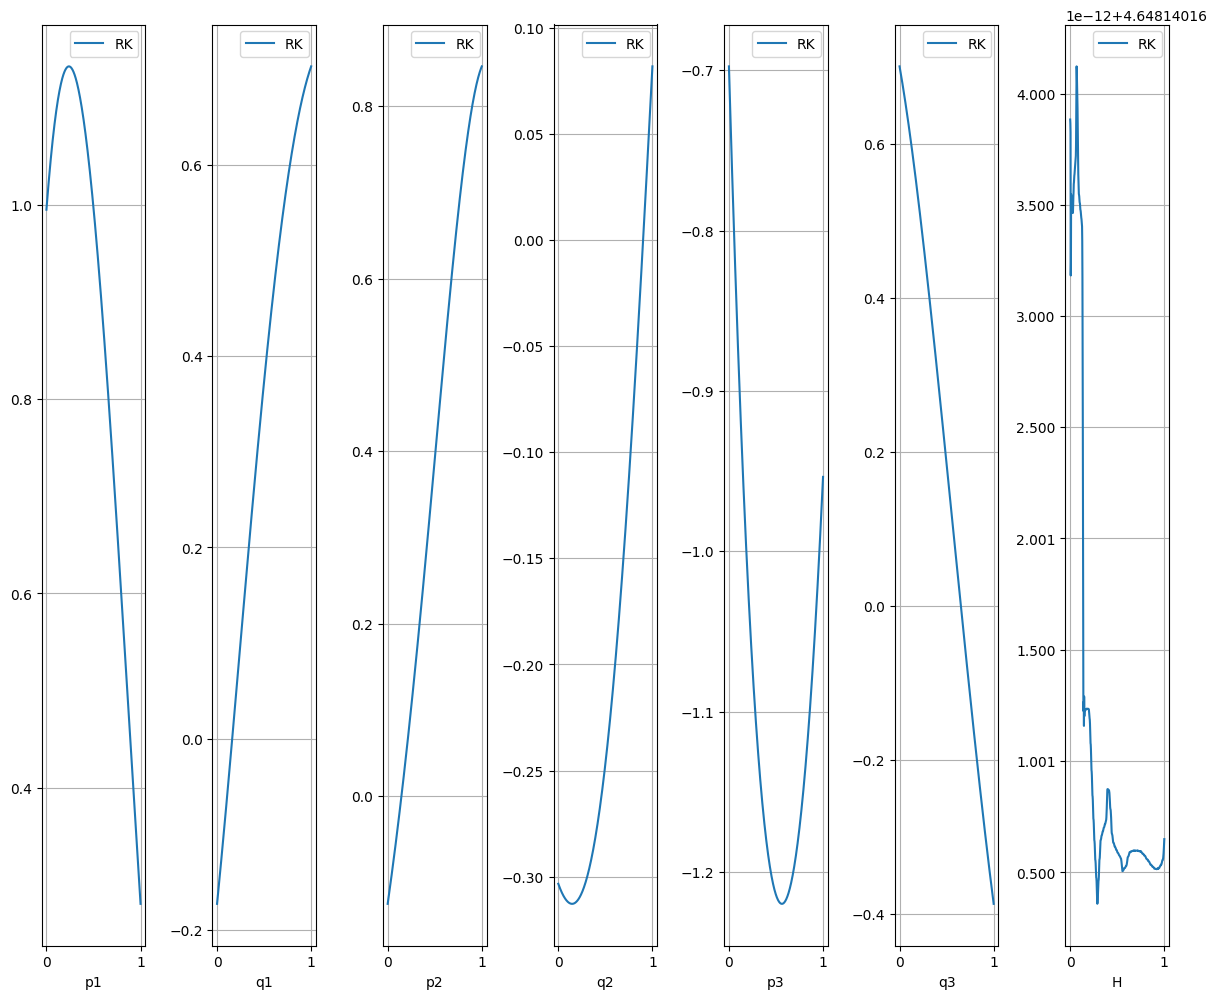

In [53]:
fig = plt.figure(figsize=(12, 10))

plt.subplot(1, 7, 1)
plt.tight_layout()
plt.plot(t, p1_rk, label = 'RK')
plt.xlabel("p1")
plt.grid()
plt.legend()

plt.subplot(1, 7, 2)
plt.tight_layout()
plt.plot(t, q1_rk, label = 'RK')
plt.xlabel("q1")
plt.grid()
plt.legend()

plt.subplot(1, 7, 3)
plt.tight_layout()
plt.plot(t, p2_rk, label = 'RK')
plt.xlabel("p2")
plt.grid()
plt.legend()

plt.subplot(1, 7, 4)
plt.tight_layout()
plt.plot(t, q2_rk, label = 'RK')
plt.xlabel("q2")
plt.grid()
plt.legend()

plt.subplot(1, 7, 5)
plt.tight_layout()
plt.plot(t, p3_rk, label = 'RK')
plt.xlabel("p3")
plt.grid()
plt.legend()

plt.subplot(1, 7, 6)
plt.tight_layout()
plt.plot(t, q3_rk, label = 'RK')
plt.xlabel("q3")
plt.grid()
plt.legend()

plt.subplot(1, 7, 7)
plt.tight_layout()
plt.plot(t, H_rk, label = 'RK')
plt.xlabel("H")
plt.grid()
plt.legend()

In [54]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [55]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [56]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [57]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(6*self.units)(b)
    return out

In [58]:
def define_collocation_points(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

    p1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    p2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    p3s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q3s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    Hs = calc_H(p1s, p2s, p3s, q1s, q2s, q3s)
    
    _, evals = jax.vmap(compute_H, [0, 0, 0, 0, 0, 0])(p1s.reshape(-1), p2s.reshape(-1), p3s.reshape(-1), q1s.reshape(-1), q2s.reshape(-1), q3s.reshape(-1))


    ode_points = np.column_stack((ode_points, Hs, evals))
    zsensors = np.column_stack((p1s, q1s, p2s, q2s, p3s, q3s))
    
    return (ode_points, zsensors)

In [59]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, zsensors.shape)

(3,)
(1000, 5) (1000, 6)


In [60]:
class VDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1)) 

    t_0 = t[:, :1]
    H_0 = t[:, 1:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
   
    p1_0 = u[:, :1]
    q1_0 = u[:, 1:2]
    p2_0 = u[:, 2:3]
    q2_0 = u[:, 3:4]
    p3_0 = u[:, 4:5]
    q3_0 = u[:, 5:]

    u = jnp.column_stack((p1_0, q1_0, p2_0, q2_0, p3_0, q3_0))

    b = t_0_norm
    #b = jnp.column_stack((t_0_norm, H_0))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_q1 = trunk_net[:, self.units:2*self.units]
    trunk_p2 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q2 = trunk_net[:, 3*self.units:4*self.units]
    trunk_p3 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q3 = trunk_net[:, 5*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_q1 = branch_net[:, self.units:2*self.units]
    branch_p2 = branch_net[:, 2*self.units:3*self.units]
    branch_q2 = branch_net[:, 3*self.units:4*self.units]
    branch_p3 = branch_net[:, 4*self.units:5*self.units]
    branch_q3 = branch_net[:, 5*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    q3 = CombineBranches()(trunk_q3, branch_q3)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])
      
    p1 = jnp.reshape(p1, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    q3 = jnp.reshape(q3, (-1,))

    return p1, q1, p2, q2, p3, q3

In [61]:
@partial(jax.jit, static_argnums=(2,))
def Vvar_model(t, z, component, params):
  return Vdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Vvar(t, z, component, params):
  return jax.vmap(Vvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Vvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Vvar_model, 0), [0, 0, None, None])(t, z, component, params)


@jax.jit
def Vloss(params, t, z):
    
    p1_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    q2_t_loss_w = 1.0
    p3_t_loss_w = 1.0
    q3_t_loss_w = 1.0    
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    H_0 = t[:, -1]
    
    p1_0 = z[:, :1]
    q1_0 = z[:, 1:2]
    p2_0 = z[:, 2:3]
    q2_0 = z[:, 3:4]
    p3_0 = z[:, 4:5]
    q3_0 = z[:, 5:]
    
    p1 = Vvar(t, z, 0, params)
    q1 = Vvar(t, z, 1, params)
    p2 = Vvar(t, z, 2, params)
    q2 = Vvar(t, z, 3, params)
    p3 = Vvar(t, z, 4, params)
    q3 = Vvar(t, z, 5, params)
    
    H = calc_H(p1, p2, p3, q1, q2, q3)
    
    dp1_t = Vvar_t(t, z, 0, params)
    dq1_t = Vvar_t(t, z, 1, params)
    dp2_t = Vvar_t(t, z, 2, params)
    dq2_t = Vvar_t(t, z, 3, params)
    dp3_t = Vvar_t(t, z, 4, params)
    dq3_t = Vvar_t(t, z, 5, params)
        
    p1_t = dp1_t[:, 0]
    q1_t = dq1_t[:, 0]  
    p2_t = dp2_t[:, 0]
    q2_t = dq2_t[:, 0]
    p3_t = dp3_t[:, 0]
    q3_t = dq3_t[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t + jnp.exp(q1 - q2)
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - jnp.exp(q2 - q3)
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)
        
    diff_loss = p1_t_loss_w*p1_t_loss +  q1_t_loss_w*q1_t_loss + p2_t_loss_w*p2_t_loss + q2_t_loss_w*q2_t_loss + \
                p3_t_loss_w*p3_t_loss + q3_t_loss_w*q3_t_loss

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss

@jax.jit
def Vtrain_step(params, pdes, z):
    t = pdes[:, :]
    
    return jax.value_and_grad(Vloss, has_aux = False)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Voptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [62]:
def Vtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = Vtrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = Voptimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [63]:
Vdeeponet = VDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 6), 1.0)

Vparams = Vdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [64]:
Vparam_count = sum(x.size for x in jax.tree.leaves(Vparams))
print(Vparam_count)

26600


In [65]:
print(de_points.shape, zsensors.shape)

(1000, 5) (1000, 6)


In [66]:
# epochs = 1000
# Vparams, Vloss = Vtrain_network(Vparams, de_points, zsensors, epochs)

# plt.semilogy(Vloss)
# plt.grid()

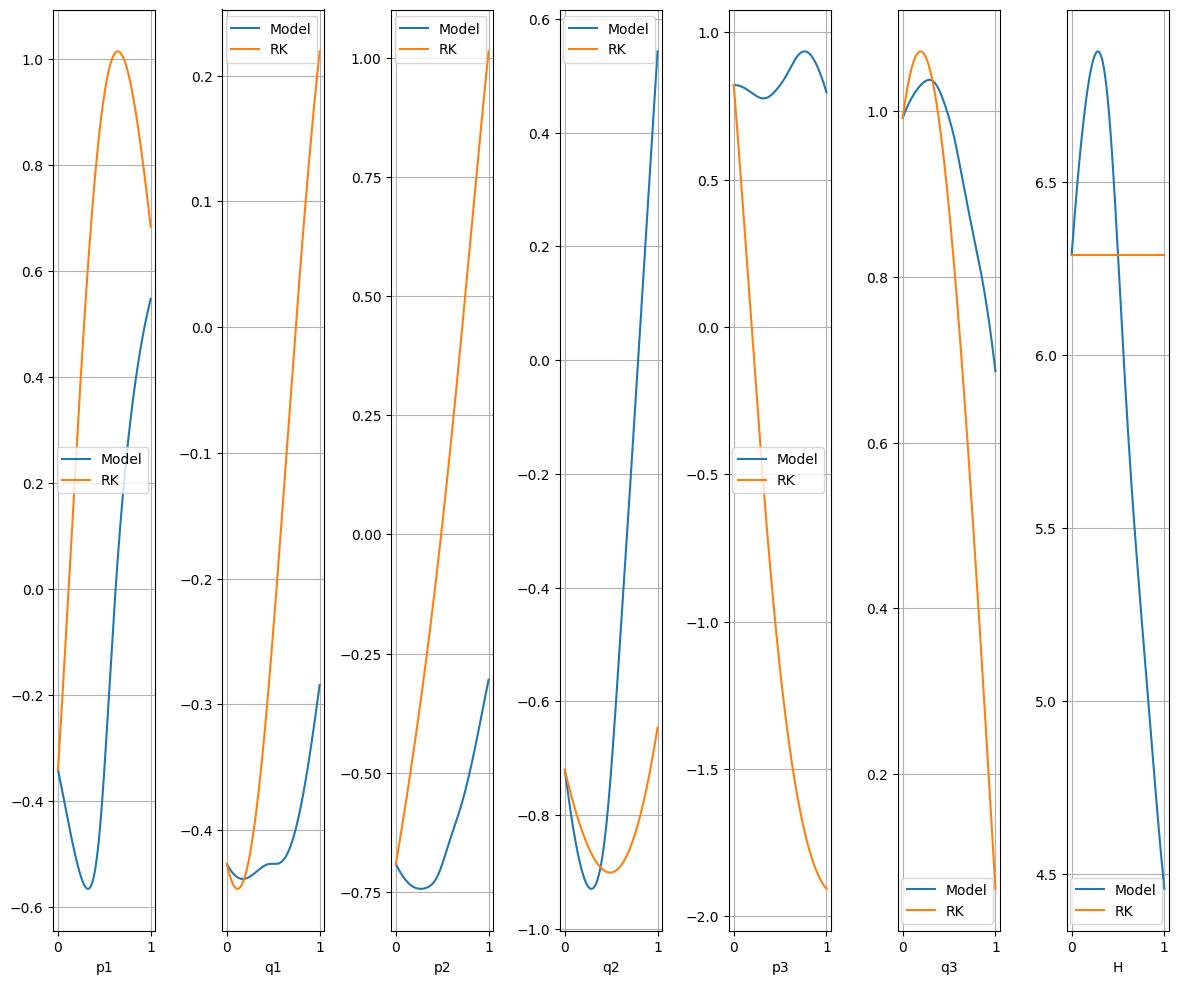

In [67]:
n = 500
t = np.linspace(t0, tfinal, n)

p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
H_init = (p1_init**2)/2 + (p2_init**2)/2 + (p3_init**2)/2 + jnp.exp(q1_init - q2_init) + jnp.exp(q2_init - q3_init) + + jnp.exp(q3_init - q1_init)

data_model = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
data_model = np.reshape(data_model, (-1,))
data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
t_model = np.column_stack([t, H_model])

p1 = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 0, Vparams)
q1 = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 1, Vparams)
p2 = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 2, Vparams)
q2 = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 3, Vparams)
p3 = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 4, Vparams)
q3 = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 5, Vparams)
H = (p1**2)/2 + (p2**2)/2 + (p3**2)/2 + jnp.exp(q1 - q2) + jnp.exp(q2 - q3) + jnp.exp(q3 - q1)

data_rk = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t

sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
p1_rk, q1_rk, p2_rk, q2_rk, p3_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
H_rk = (p1_rk**2)/2 + (p2_rk**2)/2 + (p3_rk**2)/2 + jnp.exp(q1_rk - q2_rk) + jnp.exp(q2_rk - q3_rk) + + jnp.exp(q3_rk - q1_rk)

fig = plt.figure(figsize=(12, 10))

plt.subplot(1, 7, 1)
plt.tight_layout()
plt.plot(t, p1, label = 'Model')
plt.plot(t, p1_rk, label = 'RK')
plt.xlabel("p1")
plt.grid()
plt.legend()

plt.subplot(1, 7, 2)
plt.tight_layout()
plt.plot(t, q1, label = 'Model')
plt.plot(t, q1_rk, label = 'RK')
plt.xlabel("q1")
plt.grid()
plt.legend()

plt.subplot(1, 7, 3)
plt.tight_layout()
plt.plot(t, p2, label = 'Model')
plt.plot(t, p2_rk, label = 'RK')
plt.xlabel("p2")
plt.grid()
plt.legend()

plt.subplot(1, 7, 4)
plt.tight_layout()
plt.plot(t, q2, label = 'Model')
plt.plot(t, q2_rk, label = 'RK')
plt.xlabel("q2")
plt.grid()
plt.legend()

plt.subplot(1, 7, 5)
plt.tight_layout()
plt.plot(t, p3, label = 'Model')
plt.plot(t, p3_rk, label = 'RK')
plt.xlabel("p3")
plt.grid()
plt.legend()

plt.subplot(1, 7, 6)
plt.tight_layout()
plt.plot(t, q3, label = 'Model')
plt.plot(t, q3_rk, label = 'RK')
plt.xlabel("q3")
plt.grid()
plt.legend()

plt.subplot(1, 7, 7)
plt.tight_layout()
plt.plot(t, H, label = 'Model')
plt.plot(t, H_rk, label = 'RK')
plt.xlabel("H")
plt.grid()
plt.legend()

In [68]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1)) 

    t_0 = t[:, :1]
    H_0 = t[:, 1:2]
    eval1_0 = t[:, 2:3]
    eval2_0 = t[:, 3:4]
    eval3_0 = t[:, 4:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
   
    p1_0 = u[:, :1]
    q1_0 = u[:, 1:2]
    p2_0 = u[:, 2:3]
    q2_0 = u[:, 3:4]
    p3_0 = u[:, 4:5]
    q3_0 = u[:, 5:]

    u = jnp.column_stack((p1_0, q1_0, p2_0, q2_0, p3_0, q3_0))

    b = t_0_norm
    # b = jnp.column_stack((t_0_norm, H_0))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_q1 = trunk_net[:, self.units:2*self.units]
    trunk_p2 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q2 = trunk_net[:, 3*self.units:4*self.units]
    trunk_p3 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q3 = trunk_net[:, 5*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_q1 = branch_net[:, self.units:2*self.units]
    branch_p2 = branch_net[:, 2*self.units:3*self.units]
    branch_q2 = branch_net[:, 3*self.units:4*self.units]
    branch_p3 = branch_net[:, 4*self.units:5*self.units]
    branch_q3 = branch_net[:, 5*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    q3 = CombineBranches()(trunk_q3, branch_q3)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])
      
    p1 = jnp.reshape(p1, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    q3 = jnp.reshape(q3, (-1,))

    return p1, q1, p2, q2, p3, q3

In [69]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):
    
    p1_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    q2_t_loss_w = 1.0
    p3_t_loss_w = 1.0
    q3_t_loss_w = 1.0    
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    t_0 = t[:, :1]
    H_0 = t[:, 1:2]
    # eval1_0 = t[:, 2:3]
    # eval2_0 = t[:, 3:4]
    # eval3_0 = t[:, 4:]
    
    p1_0 = z[:, :1]
    q1_0 = z[:, 1:2]
    p2_0 = z[:, 2:3]
    q2_0 = z[:, 3:4]
    p3_0 = z[:, 4:5]
    q3_0 = z[:, 5:]
    
    p1 = var(t, z, 0, params)
    q1 = var(t, z, 1, params)
    p2 = var(t, z, 2, params)
    q2 = var(t, z, 3, params)
    p3 = var(t, z, 4, params)
    q3 = var(t, z, 5, params)
    
    H = calc_H(p1, p2, p3, q1, q2, q3)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_t = var_t(t, z, 0, params)
    dq1_t = var_t(t, z, 1, params)
    dp2_t = var_t(t, z, 2, params)
    dq2_t = var_t(t, z, 3, params)
    dp3_t = var_t(t, z, 4, params)
    dq3_t = var_t(t, z, 5, params)
        
    p1_t = dp1_t[:, 0]
    q1_t = dq1_t[:, 0]  
    p2_t = dp2_t[:, 0]
    q2_t = dq2_t[:, 0]
    p3_t = dp3_t[:, 0]
    q3_t = dq3_t[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q3 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q1))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)
        
    diff_loss = p1_t_loss_w*p1_t_loss +  q1_t_loss_w*q1_t_loss + p2_t_loss_w*p2_t_loss + q2_t_loss_w*q2_t_loss + \
                p3_t_loss_w*p3_t_loss + q3_t_loss_w*q3_t_loss

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss

@jax.jit
def train_step(params, pdes, z):
    t = pdes[:, :]
    
    return jax.value_and_grad(loss, has_aux = False)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [70]:
def train_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = optimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [71]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 5), 1.0)
u_init = jnp.full((10, 6), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [72]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

26600


batch size: 100
Loss in epoch 0: 1.38267710932366
Loss in epoch 100: 0.017818668340470828


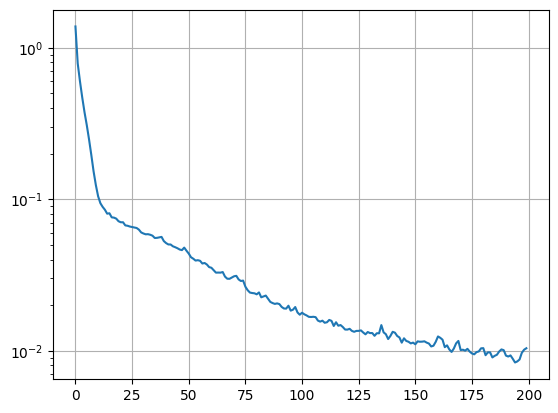

In [73]:
epochs = 200
params, loss = train_network(params, de_points, zsensors, epochs)

plt.semilogy(loss)
plt.grid()

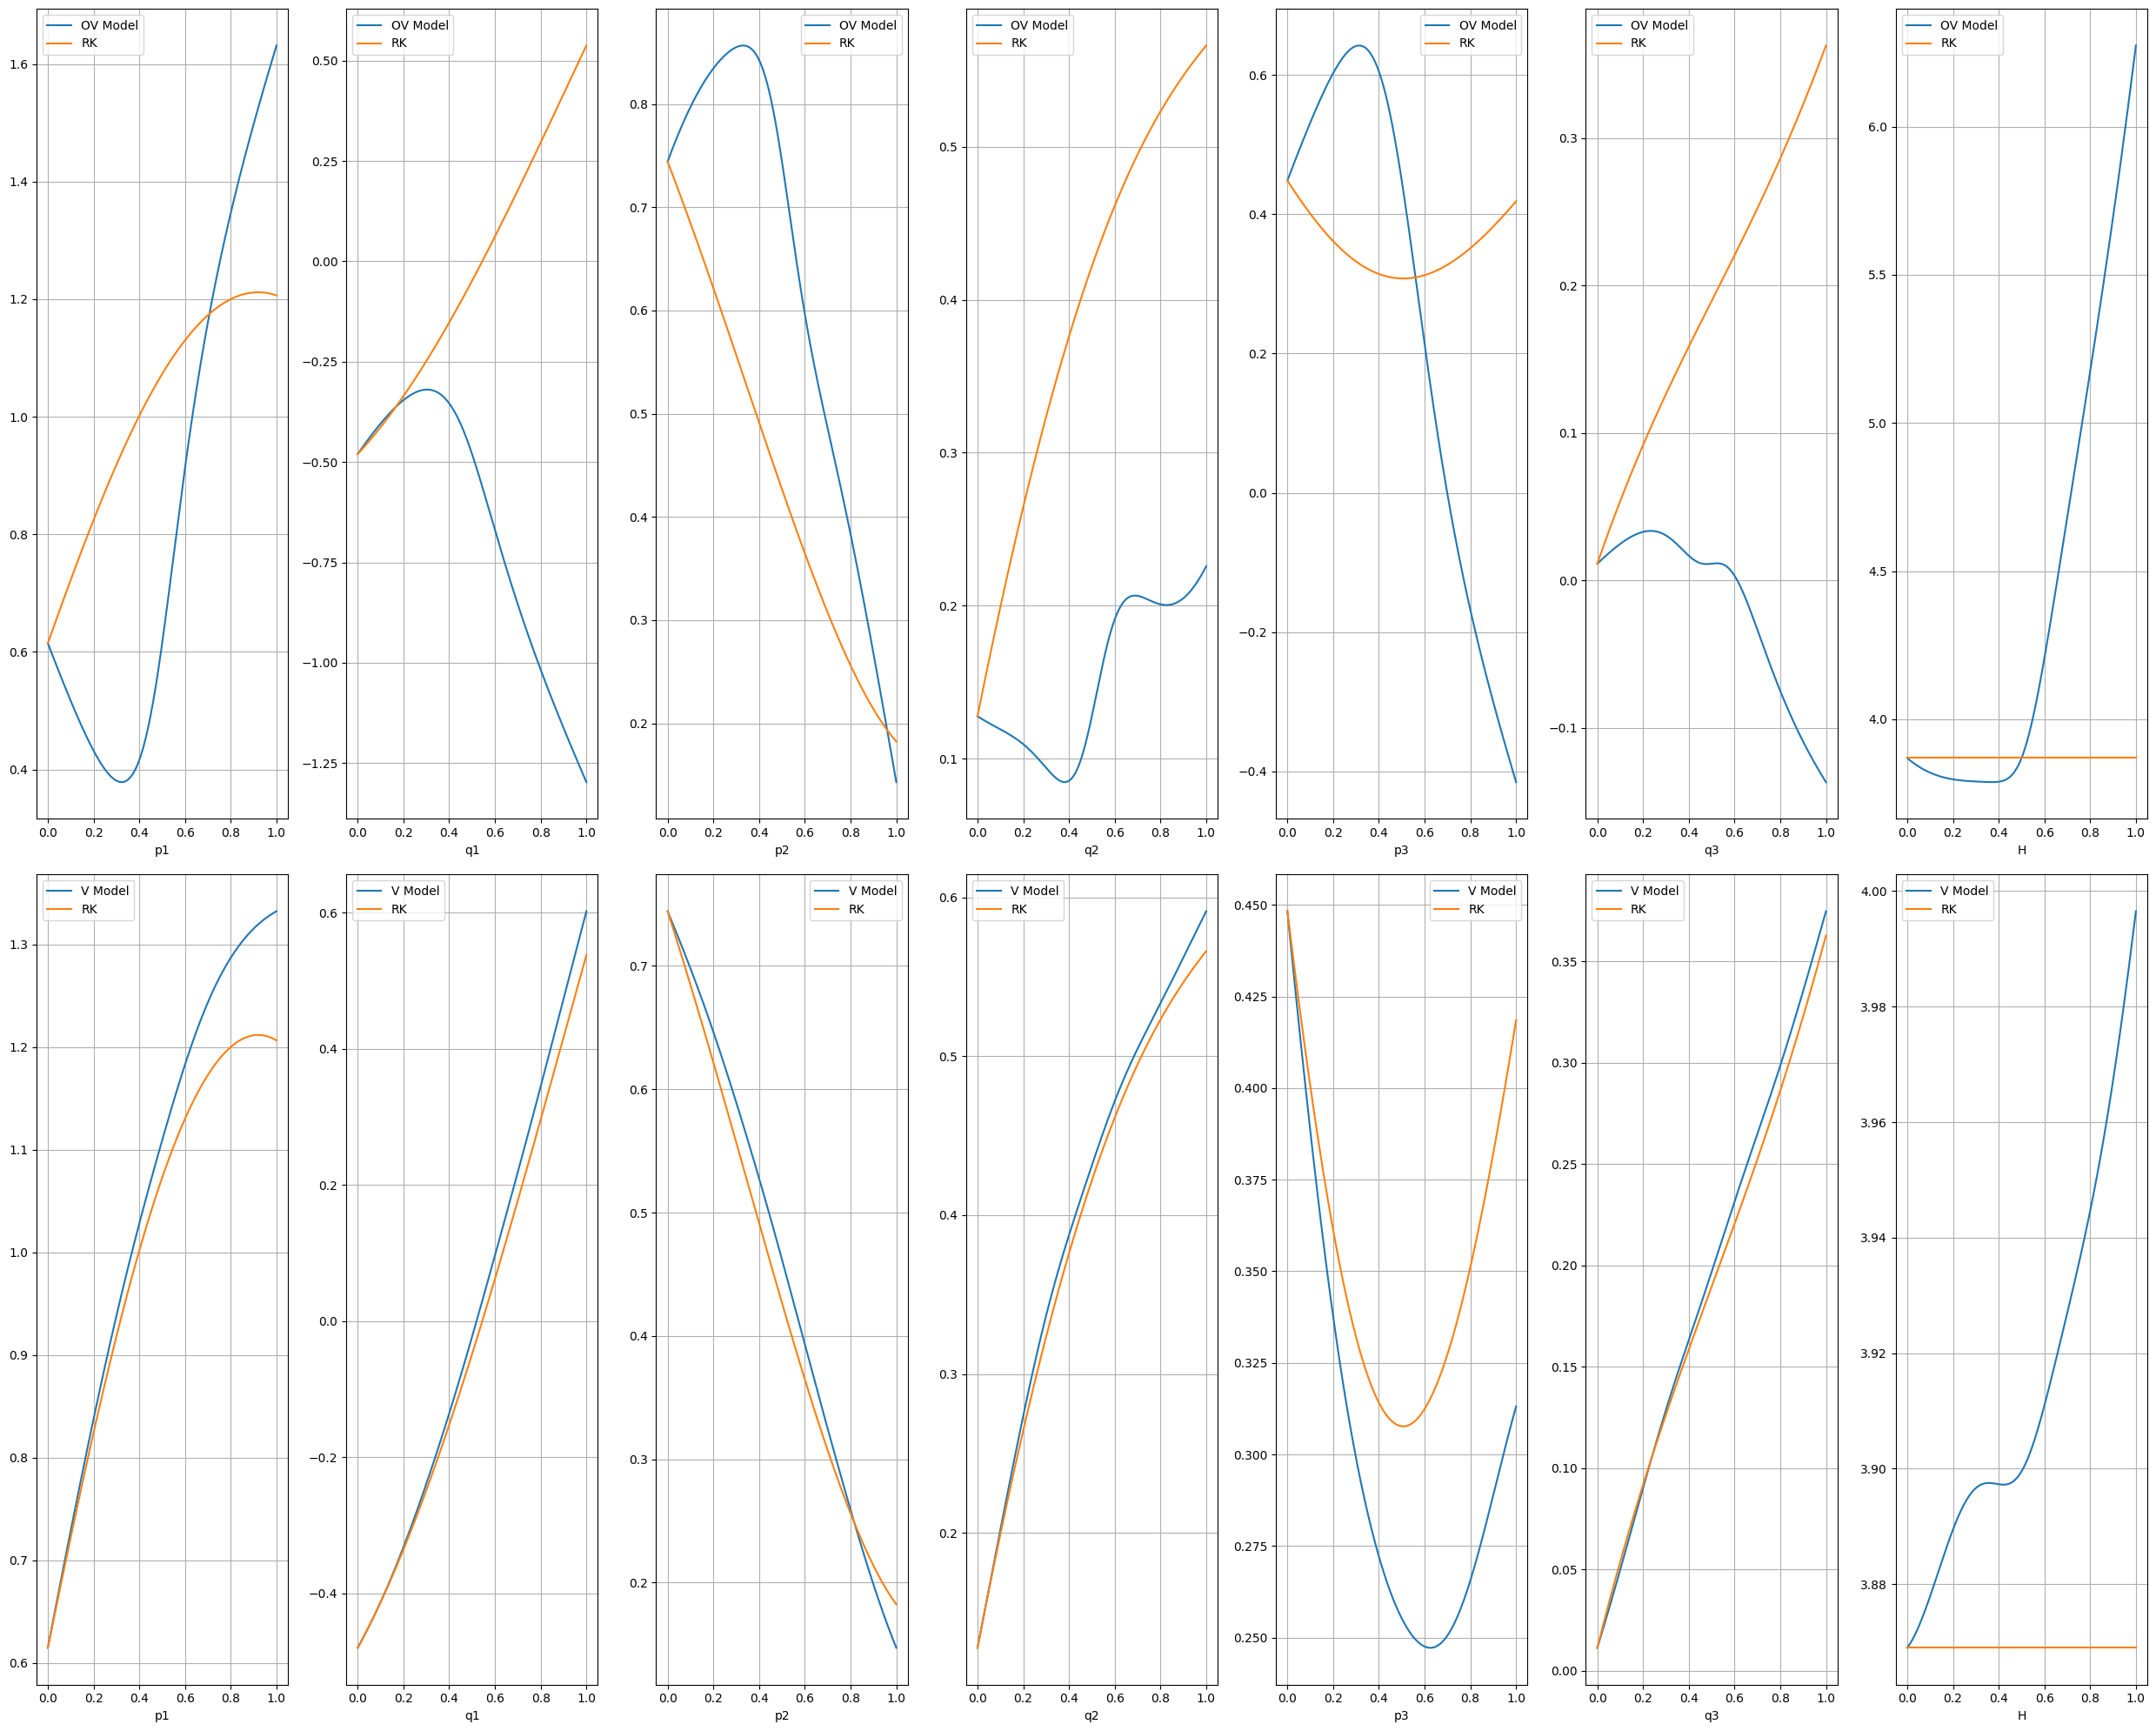

In [74]:
n = 500
t = np.linspace(t0, tfinal, n)

p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)

data_model = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
data_model = np.reshape(data_model, (-1,))
data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
t_model = np.column_stack([t, H_model])

data_rk = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t

sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
p1_rk, q1_rk, p2_rk, q2_rk, p3_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)

H_data = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
tH_data = np.column_stack([t, H_data])


p1ov = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 0, Vparams)
q1ov = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 1, Vparams)
p2ov = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 2, Vparams)
q2ov = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 3, Vparams)
p3ov = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 4, Vparams)
q3ov = jax.vmap(Vvar_model, [0, 0, None, None])(t_model, data_model, 5, Vparams)
Hov = calc_H(p1ov, p2ov, p3ov, q1ov, q2ov, q3ov)

p1v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 0, params)
q1v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 1, params)
p2v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 2, params)
q2v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 3, params)
p3v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 4, params)
q3v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 5, params)
Hv = calc_H(p1v, p2v, p3v, q1v, q2v, q3v)

fig = plt.figure(figsize=(25, 20))

plt.subplot(2, 7, 1)
plt.tight_layout()
plt.plot(t, p1ov, label = 'OV Model')
plt.plot(t, p1_rk, label = 'RK')
plt.xlabel("p1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 2)
plt.tight_layout()
plt.plot(t, q1ov, label = 'OV Model')
plt.plot(t, q1_rk, label = 'RK')
plt.xlabel("q1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 3)
plt.tight_layout()
plt.plot(t, p2ov, label = 'OV Model')
plt.plot(t, p2_rk, label = 'RK')
plt.xlabel("p2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 4)
plt.tight_layout()
plt.plot(t, q2ov, label = 'OV Model')
plt.plot(t, q2_rk, label = 'RK')
plt.xlabel("q2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 5)
plt.tight_layout()
plt.plot(t, p3ov, label = 'OV Model')
plt.plot(t, p3_rk, label = 'RK')
plt.xlabel("p3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 6)
plt.tight_layout()
plt.plot(t, q3ov, label = 'OV Model')
plt.plot(t, q3_rk, label = 'RK')
plt.xlabel("q3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 7)
plt.tight_layout()
plt.plot(t, Hov, label = 'OV Model')
plt.plot(t, H_rk, label = 'RK')
plt.xlabel("H")
plt.grid()
plt.legend()

plt.subplot(2, 7, 8)
plt.tight_layout()
plt.plot(t, p1v, label = 'V Model')
plt.plot(t, p1_rk, label = 'RK')
plt.xlabel("p1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 9)
plt.tight_layout()
plt.plot(t, q1v, label = 'V Model')
plt.plot(t, q1_rk, label = 'RK')
plt.xlabel("q1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 10)
plt.tight_layout()
plt.plot(t, p2v, label = 'V Model')
plt.plot(t, p2_rk, label = 'RK')
plt.xlabel("p2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 11)
plt.tight_layout()
plt.plot(t, q2v, label = 'V Model')
plt.plot(t, q2_rk, label = 'RK')
plt.xlabel("q2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 12)
plt.tight_layout()
plt.plot(t, p3v, label = 'V Model')
plt.plot(t, p3_rk, label = 'RK')
plt.xlabel("p3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 13)
plt.tight_layout()
plt.plot(t, q3v, label = 'V Model')
plt.plot(t, q3_rk, label = 'RK')
plt.xlabel("q3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 14)
plt.tight_layout()
plt.plot(t, Hv, label = 'V Model')
plt.plot(t, H_rk, label = 'RK')
plt.xlabel("H")
plt.grid()
plt.legend()

In [75]:
class EDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1)) 

    t_0 = t[:, :1]
    H_0 = t[:, 1:2]
    eval1_0 = t[:, 2:3]
    eval2_0 = t[:, 3:4]
    eval3_0 = t[:, 4:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
   
    p1_0 = u[:, :1]
    q1_0 = u[:, 1:2]
    p2_0 = u[:, 2:3]
    q2_0 = u[:, 3:4]
    p3_0 = u[:, 4:5]
    q3_0 = u[:, 5:]

    u = jnp.column_stack((p1_0, q1_0, p2_0, q2_0, p3_0, q3_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_q1 = trunk_net[:, self.units:2*self.units]
    trunk_p2 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q2 = trunk_net[:, 3*self.units:4*self.units]
    trunk_p3 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q3 = trunk_net[:, 5*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_q1 = branch_net[:, self.units:2*self.units]
    branch_p2 = branch_net[:, 2*self.units:3*self.units]
    branch_q2 = branch_net[:, 3*self.units:4*self.units]
    branch_p3 = branch_net[:, 4*self.units:5*self.units]
    branch_q3 = branch_net[:, 5*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    q3 = CombineBranches()(trunk_q3, branch_q3)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])
      
    p1 = jnp.reshape(p1, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    q3 = jnp.reshape(q3, (-1,))

    evals = jax.vmap(calc_evals_pq, [0])((p1, p2, p3, q1, q2, q3))

    eval1 = evals[:, :1]
    eval2 = evals[:, 1:2]
    eval3 = evals[:, 2:]

    eval1 = jnp.reshape(eval1, (-1,))
    eval2 = jnp.reshape(eval2, (-1,))
    eval3 = jnp.reshape(eval3, (-1,))      

    return p1, q1, p2, q2, p3, q3, eval1, eval2, eval3

In [76]:
@jax.jit
def rem_dim(x) :

    return jnp.reshape(x, (-1,))

In [77]:
@partial(jax.jit, static_argnums=(2,))
def Evar_model(t, z, component, params):
  return Edeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Evar(t, z, component, params):
  return jax.vmap(Evar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Evar_t(t, z, component, params):
  return jax.vmap(jax.grad(Evar_model, 0), [0, 0, None, None])(t, z, component, params)       
    
@jax.jit
def Eloss(params, t, z):
    
    p1_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    q2_t_loss_w = 1.0
    p3_t_loss_w = 1.0
    q3_t_loss_w = 1.0    
    
    diff_loss_w = 1.0
    H_loss_w = 1.0
    eval1_loss_w = 0.0
    eval2_loss_w = 0.0
    eval3_loss_w = 0.0

    t_0 = t[:, :1]
    
    H_0 = rem_dim(t[:, 1:2])
    eval1_0 = rem_dim(t[:, 2:3])
    eval2_0 = rem_dim(t[:, 3:4])
    eval3_0 = rem_dim(t[:, 4:])
    
    p1_0 = z[:, :1]
    q1_0 = z[:, 1:2]
    p2_0 = z[:, 2:3]
    q2_0 = z[:, 3:4]
    p3_0 = z[:, 4:5]
    q3_0 = z[:, 5:]

    p1 = Evar(t, z, 0, params)
    q1 = Evar(t, z, 1, params)
    p2 = Evar(t, z, 2, params)
    q2 = Evar(t, z, 3, params)
    p3 = Evar(t, z, 4, params)
    q3 = Evar(t, z, 5, params)
    eval1 = Evar(t, z, 6, params)
    eval2 = Evar(t, z, 7, params)
    eval3 = Evar(t, z, 8, params)
    
    H = calc_H(p1, p2, p3, q1, q2, q3)
    
    dp1_t = Evar_t(t, z, 0, params)
    dq1_t = Evar_t(t, z, 1, params)
    dp2_t = Evar_t(t, z, 2, params)
    dq2_t = Evar_t(t, z, 3, params)
    dp3_t = Evar_t(t, z, 4, params)
    dq3_t = Evar_t(t, z, 5, params)
    deval1_t = Evar_t(t, z, 6, params)
    deval2_t = Evar_t(t, z, 7, params)
    deval3_t = Evar_t(t, z, 8, params)
        
    p1_t = dp1_t[:, 0]
    q1_t = dq1_t[:, 0]  
    p2_t = dp2_t[:, 0]
    q2_t = dq2_t[:, 0]
    p3_t = dp3_t[:, 0]
    q3_t = dq3_t[:, 0]
    eval1_t = deval1_t[:, 0]
    eval2_t = deval2_t[:, 0]
    eval3_t = deval3_t[:, 0]

    evals_t_loss = jnp.mean(eval1_t**2) + jnp.mean(eval2_t**2) + jnp.mean(eval3_t**2)

    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q3 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q1))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)
        
    diff_loss = p1_t_loss_w*p1_t_loss +  q1_t_loss_w*q1_t_loss + p2_t_loss_w*p2_t_loss + q2_t_loss_w*q2_t_loss + \
                p3_t_loss_w*p3_t_loss + q3_t_loss_w*q3_t_loss


    evals_loss = jnp.mean((eval1 - eval1_0)**2) + jnp.mean((eval2 - eval2_0)**2) + jnp.mean((eval3 - eval3_0)**2)

    total_loss = diff_loss_w*diff_loss + H_loss
    
    return total_loss, evals_loss

@jax.jit
def Etrain_step(params, pdes, z):
    t = pdes[:, :]
    
    return jax.value_and_grad(Eloss, has_aux = True)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Eoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [78]:
def Etrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            losses, grads = Etrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = Eoptimize(grads, opt_state, params, optimizer.update)

            loss, aux_loss = losses
           
            epoch_loss[i] += loss
            epoch_aux_loss[i] += aux_loss

        epoch_loss[i] /= batch_size
        epoch_aux_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

    return params, epoch_loss

In [79]:
Edeeponet = EDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 5), 1.0)
u_init = jnp.full((10, 6), 1.0)

Eparams = Edeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

batch size: 100
Loss in epoch 0: 2.1642772317474517
Aux Loss in epoch 0: 0.037951550237899354
Loss in epoch 100: 0.02721539461340242
Aux Loss in epoch 100: 0.026627882879198265


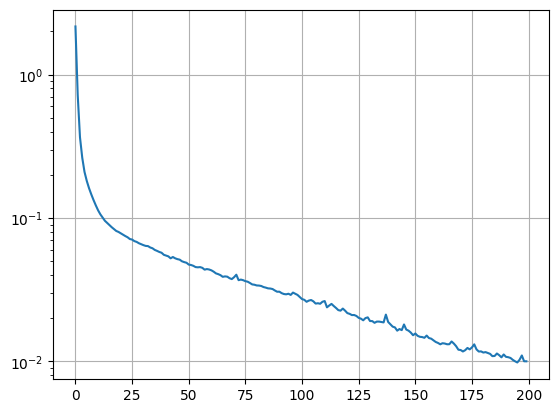

In [80]:
epochs = 200
Eparams, Eloss = Etrain_network(Eparams, de_points, zsensors, epochs)

plt.semilogy(Eloss)
plt.grid()

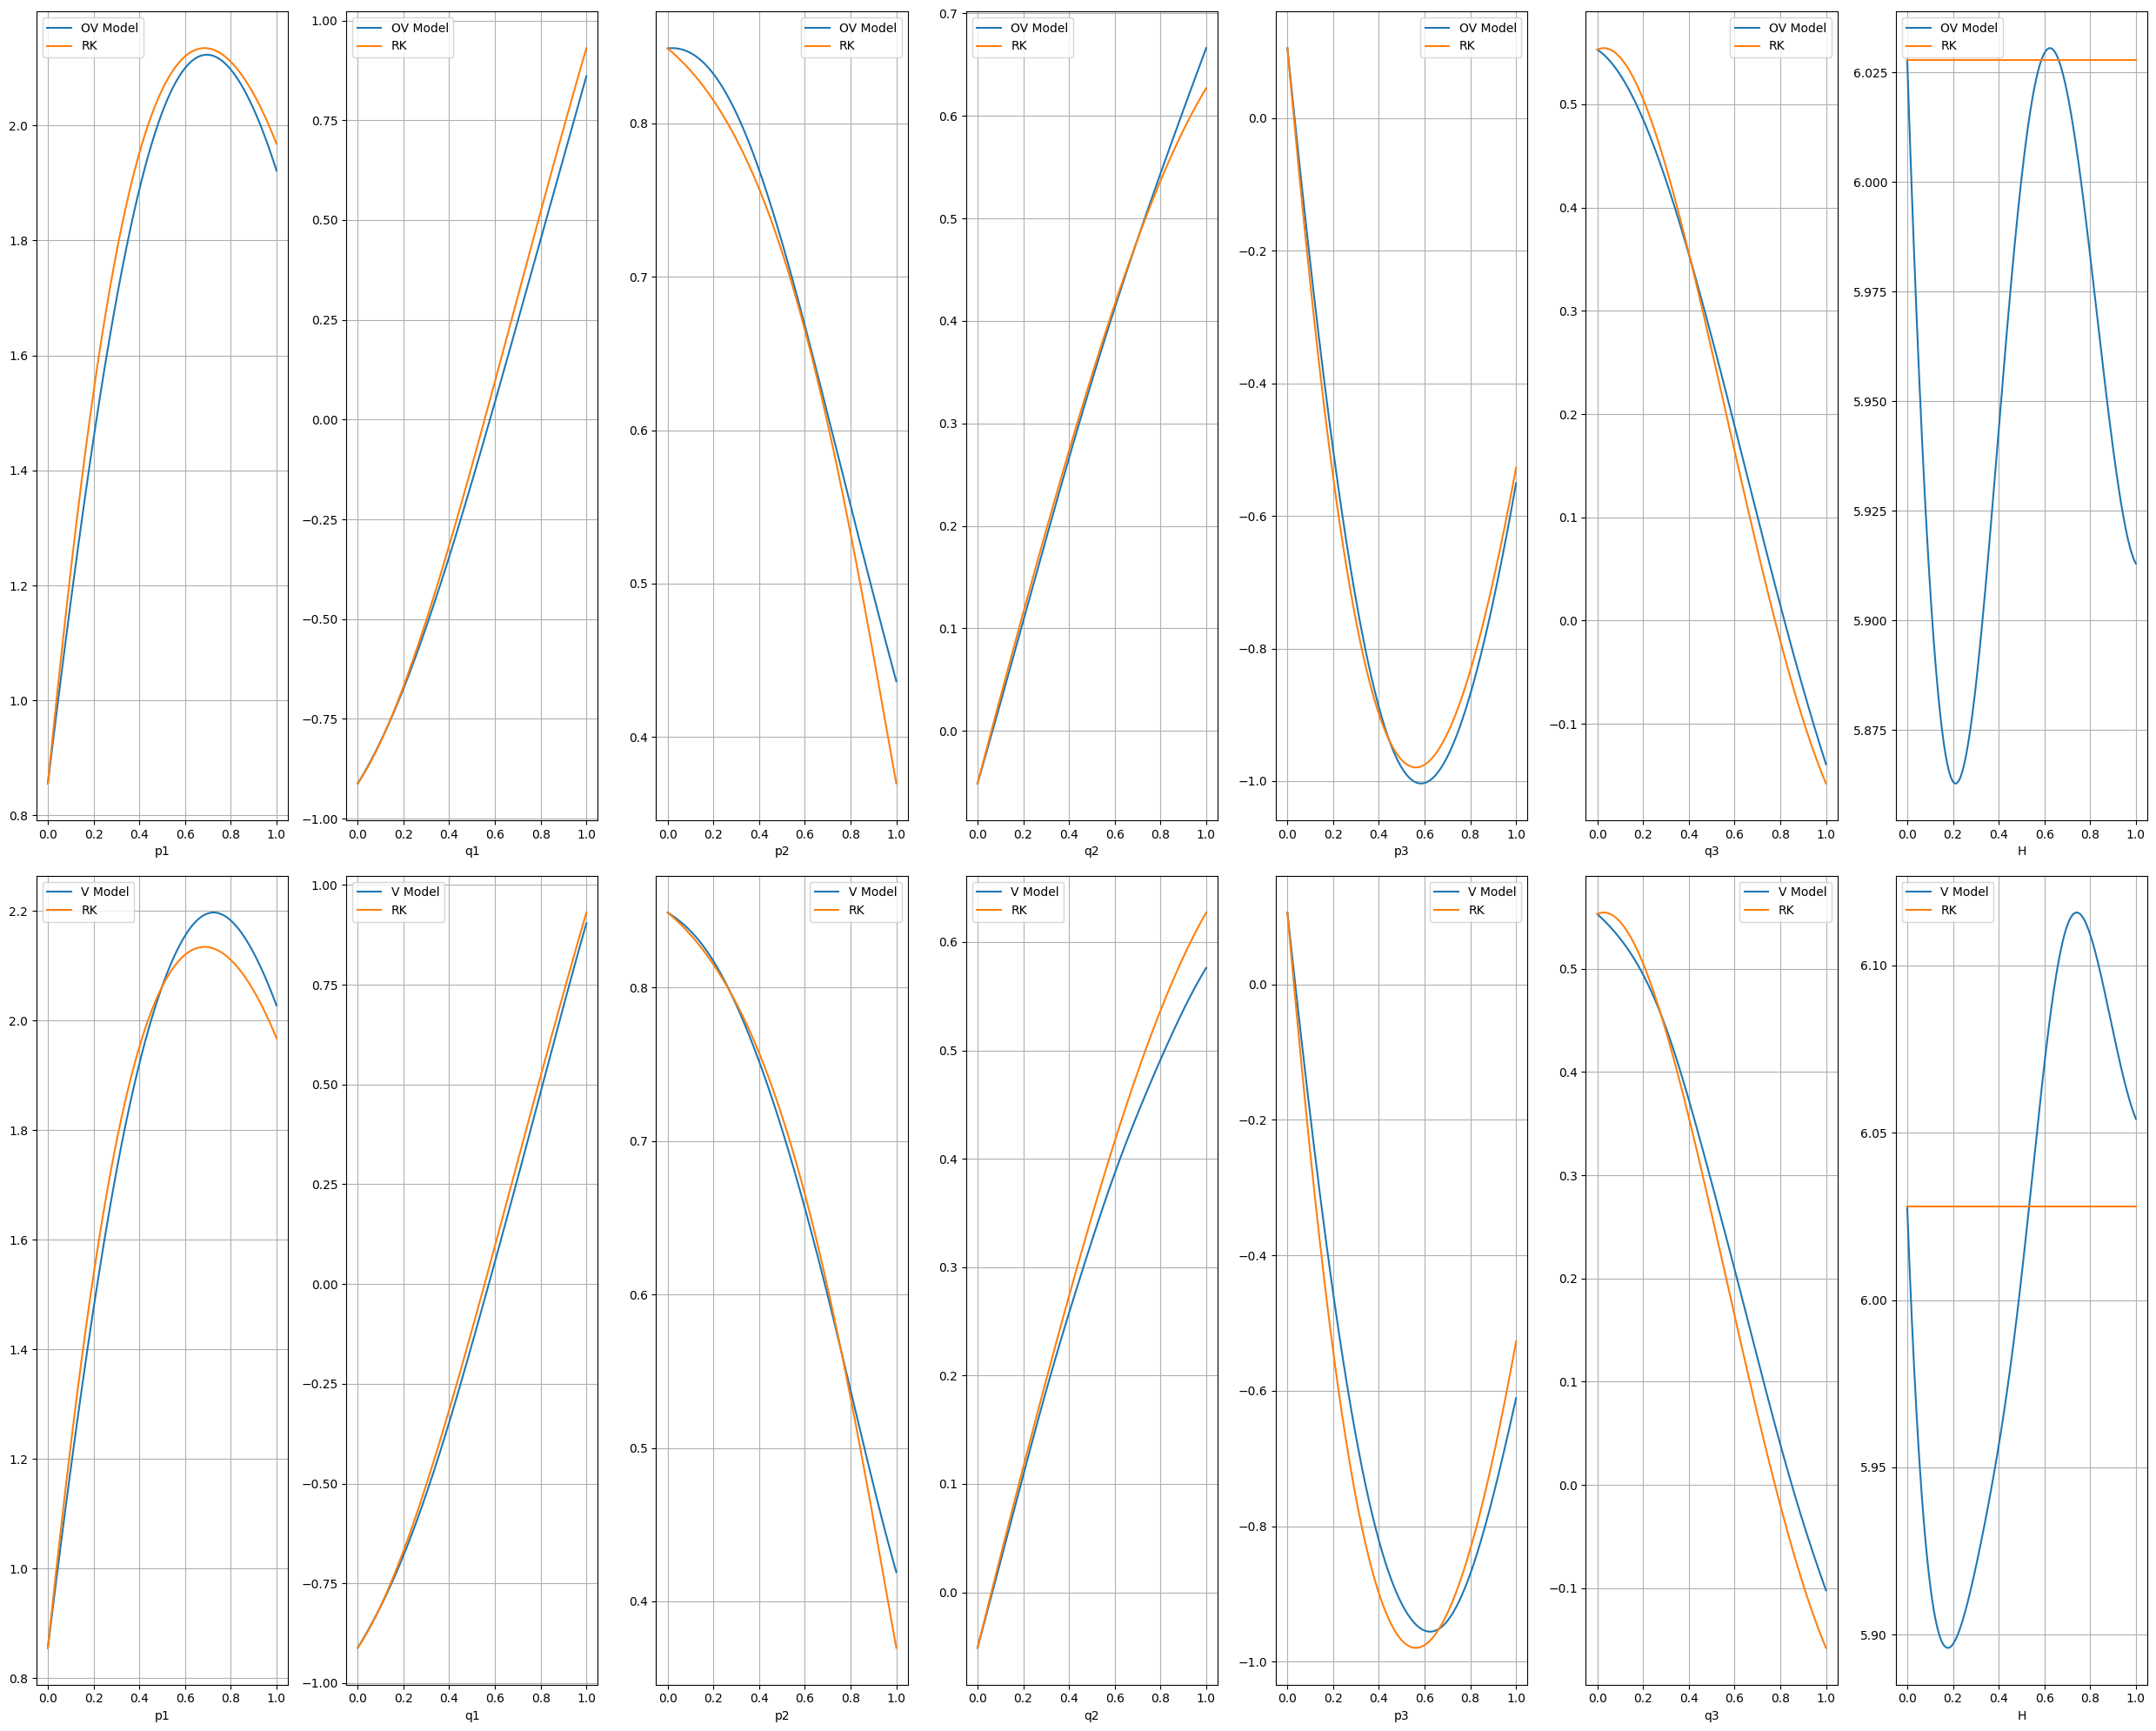

In [81]:
n = 500
t = np.linspace(t0, tfinal, n)

p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)

data_model = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
data_model = np.reshape(data_model, (-1,))
data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
t_model = np.column_stack([t, H_model])

data_rk = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t

sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
p1_rk, q1_rk, p2_rk, q2_rk, p3_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)

H_data = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
tH_data = np.column_stack([t, H_data])


p1ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 0, Eparams)
q1ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 1, Eparams)
p2ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 2, Eparams)
q2ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 3, Eparams)
p3ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 4, Eparams)
q3ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 5, Eparams)
Hov = calc_H(p1ov, p2ov, p3ov, q1ov, q2ov, q3ov)

p1v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 0, params)
q1v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 1, params)
p2v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 2, params)
q2v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 3, params)
p3v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 4, params)
q3v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 5, params)
Hv = calc_H(p1v, p2v, p3v, q1v, q2v, q3v)

fig = plt.figure(figsize=(25, 20))

plt.subplot(2, 7, 1)
plt.tight_layout()
plt.plot(t, p1ov, label = 'OV Model')
plt.plot(t, p1_rk, label = 'RK')
plt.xlabel("p1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 2)
plt.tight_layout()
plt.plot(t, q1ov, label = 'OV Model')
plt.plot(t, q1_rk, label = 'RK')
plt.xlabel("q1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 3)
plt.tight_layout()
plt.plot(t, p2ov, label = 'OV Model')
plt.plot(t, p2_rk, label = 'RK')
plt.xlabel("p2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 4)
plt.tight_layout()
plt.plot(t, q2ov, label = 'OV Model')
plt.plot(t, q2_rk, label = 'RK')
plt.xlabel("q2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 5)
plt.tight_layout()
plt.plot(t, p3ov, label = 'OV Model')
plt.plot(t, p3_rk, label = 'RK')
plt.xlabel("p3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 6)
plt.tight_layout()
plt.plot(t, q3ov, label = 'OV Model')
plt.plot(t, q3_rk, label = 'RK')
plt.xlabel("q3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 7)
plt.tight_layout()
plt.plot(t, Hov, label = 'OV Model')
plt.plot(t, H_rk, label = 'RK')
plt.xlabel("H")
plt.grid()
plt.legend()

plt.subplot(2, 7, 8)
plt.tight_layout()
plt.plot(t, p1v, label = 'V Model')
plt.plot(t, p1_rk, label = 'RK')
plt.xlabel("p1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 9)
plt.tight_layout()
plt.plot(t, q1v, label = 'V Model')
plt.plot(t, q1_rk, label = 'RK')
plt.xlabel("q1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 10)
plt.tight_layout()
plt.plot(t, p2v, label = 'V Model')
plt.plot(t, p2_rk, label = 'RK')
plt.xlabel("p2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 11)
plt.tight_layout()
plt.plot(t, q2v, label = 'V Model')
plt.plot(t, q2_rk, label = 'RK')
plt.xlabel("q2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 12)
plt.tight_layout()
plt.plot(t, p3v, label = 'V Model')
plt.plot(t, p3_rk, label = 'RK')
plt.xlabel("p3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 13)
plt.tight_layout()
plt.plot(t, q3v, label = 'V Model')
plt.plot(t, q3_rk, label = 'RK')
plt.xlabel("q3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 14)
plt.tight_layout()
plt.plot(t, Hv, label = 'V Model')
plt.plot(t, H_rk, label = 'RK')
plt.xlabel("H")
plt.grid()
plt.legend()

plt.show()

In [82]:
def run_test(k) :

    n = 500
    t = np.linspace(t0, tfinal, n)

    p1ov_errs = []
    p2ov_errs = []
    p3ov_errs = []
    q1ov_errs = []
    q2ov_errs = []
    q3ov_errs = []
    Hov_errs = []

    p1v_errs = []
    p2v_errs = []
    p3v_errs = []
    q1v_errs = []
    q2v_errs = []
    q3v_errs = []
    Hv_errs = []
    
    for i in range(k) :

        print(i)
        
        p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
        
        data_model = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
        data_model = np.reshape(data_model, (-1,))
        data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        t_model = np.column_stack([t, H_model])
        
        data_rk = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t
        
        sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        p1_rk, q1_rk, p2_rk, q2_rk, p3_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
        H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)
        H_data = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        tH_data = np.column_stack([t, H_data])
        
        
        p1ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 0, Eparams)
        q1ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 1, Eparams)
        p2ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 2, Eparams)
        q2ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 3, Eparams)
        p3ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 4, Eparams)
        q3ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 5, Eparams)
        Hov = calc_H(p1ov, p2ov, p3ov, q1ov, q2ov, q3ov)
        
        p1v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 0, params)
        q1v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 1, params)
        p2v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 2, params)
        q2v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 3, params)
        p3v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 4, params)
        q3v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 5, params)
        Hv = calc_H(p1v, p2v, p3v, q1v, q2v, q3v)

        p1ov_err = jnp.mean(jnp.abs(p1_rk - p1ov))
        p2ov_err = jnp.mean(jnp.abs(p2_rk - p2ov))
        p3ov_err = jnp.mean(jnp.abs(p3_rk - p3ov))
        q1ov_err = jnp.mean(jnp.abs(q1_rk - q1ov))
        q2ov_err = jnp.mean(jnp.abs(q2_rk - q2ov))
        q3ov_err = jnp.mean(jnp.abs(q3_rk - q3ov))
        Hov_err = jnp.mean(jnp.abs(H_rk - Hov))
    
        p1v_err = jnp.mean(jnp.abs(p1_rk - p1v))
        p2v_err = jnp.mean(jnp.abs(p2_rk - p2v))
        p3v_err = jnp.mean(jnp.abs(p3_rk - p3v))
        q1v_err = jnp.mean(jnp.abs(q1_rk - q1v))
        q2v_err = jnp.mean(jnp.abs(q2_rk - q2v))
        q3v_err = jnp.mean(jnp.abs(q3_rk - q3v))
        Hv_err = jnp.mean(jnp.abs(H_rk - Hv))

        p1ov_errs.append(p1ov_err)
        p2ov_errs.append(p2ov_err)
        p3ov_errs.append(p3ov_err)
        q1ov_errs.append(q1ov_err)
        q2ov_errs.append(q2ov_err)
        q3ov_errs.append(q3ov_err)
        Hov_errs.append(Hov_err)
        
        p1v_errs.append(p1v_err)
        p2v_errs.append(p2v_err)
        p3v_errs.append(p3v_err)
        q1v_errs.append(q1v_err)
        q2v_errs.append(q2v_err)
        q3v_errs.append(q3v_err)
        Hv_errs.append(Hv_err)

    fig = plt.figure(figsize=(25, 20))

    num = [j + 1 for j in range(k)]

    plt.subplot(7, 1, 1)
    plt.tight_layout()
    plt.plot(num, p1ov_errs, label = 'OV Model')
    plt.plot(num, p1v_errs, label = 'V Model')
    plt.xlabel("p1")
    plt.grid()
    plt.legend()
    
    plt.subplot(7, 1, 2)
    plt.tight_layout()
    plt.plot(num, q1ov_errs, label = 'OV Model')
    plt.plot(num, q1v_errs, label = 'V Model')
    plt.xlabel("q1")
    plt.grid()
    plt.legend()
    
    plt.subplot(7, 1, 3)
    plt.tight_layout()
    plt.plot(num, p2ov_errs, label = 'OV Model')
    plt.plot(num, p2v_errs, label = 'V Model')
    plt.xlabel("p2")
    plt.grid()
    plt.legend()
    
    plt.subplot(7, 1, 4)
    plt.tight_layout()
    plt.plot(num, q2ov_errs, label = 'OV Model')
    plt.plot(num, q2v_errs, label = 'V Model')
    plt.xlabel("q2")
    plt.grid()
    plt.legend()
    
    plt.subplot(7, 1, 5)
    plt.tight_layout()
    plt.plot(num, p3ov_errs, label = 'OV Model')
    plt.plot(num, p3v_errs, label = 'V Model')
    plt.xlabel("p3")
    plt.grid()
    plt.legend()
    
    plt.subplot(7, 1, 6)
    plt.tight_layout()
    plt.plot(num, q3ov_errs, label = 'OV Model')
    plt.plot(num, q3v_errs, label = 'V Model')
    plt.xlabel("q3")
    plt.grid()
    plt.legend()
    
    plt.subplot(7, 1, 7)
    plt.tight_layout()
    plt.plot(num, Hov_errs, label = 'OV Model')
    plt.plot(num, Hv_errs, label = 'V Model')
    plt.xlabel("H")
    plt.grid()
    plt.legend()
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


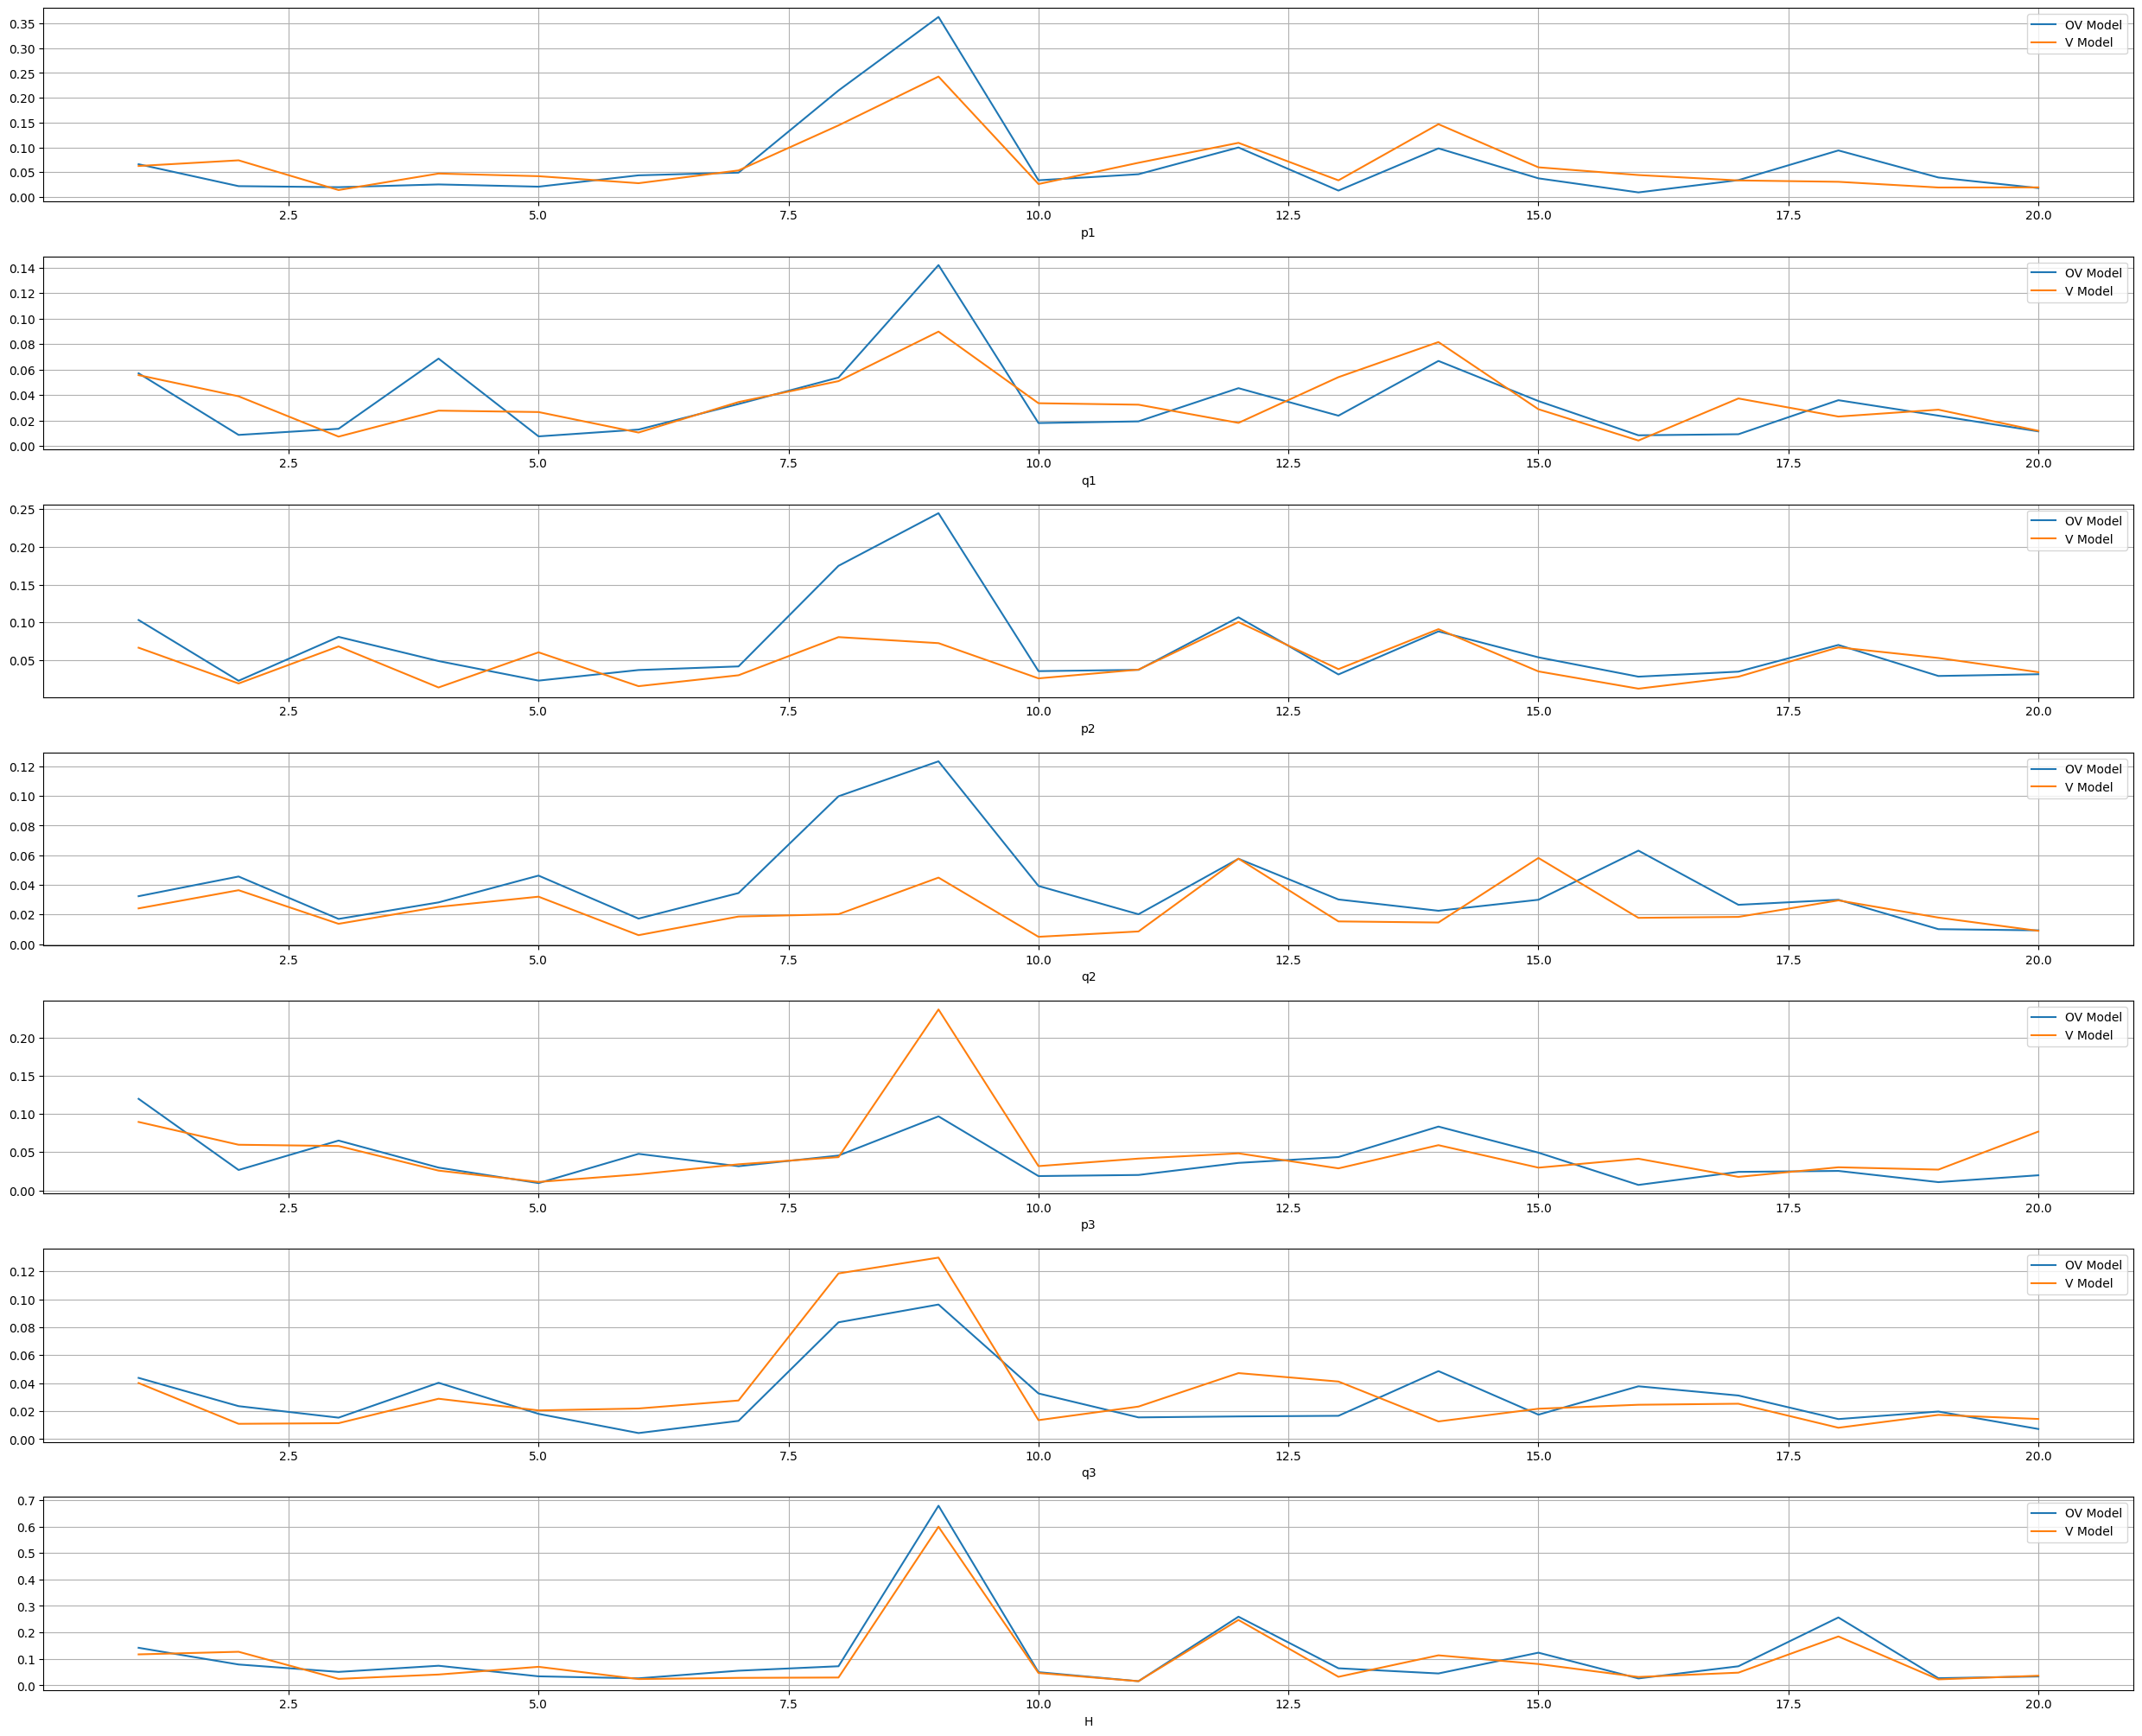

In [83]:
run_test(20)

In [84]:
@jax.jit
def loss_fun(args, e_0) :

    p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
    e1_0, e2_0, e3_0 = e_0[0], e_0[1], e_0[2]

    a1, a2, a3, b1, b2, b3 = calc_ab(args)

    args_new = (a1, a2, a3, b1, b2, b3)

    evals = calc_evals(args_new)
    
    e1 = evals[0]
    e2 = evals[1]
    e3 = evals[2]

    f1 = (e1 - e1_0)**2
    f2 = (e2 - e2_0)**2
    f3 = (e3 - e3_0)**2

    f = f1 + f2 + f3
       
    return f

In [85]:
@jax.jit
def get_derivs(args, e_0, e) :

    a1, a2, a3, b1, b2, b3 = args[0], args[1], args[2], args[3], args[4], args[5]

    dF_e = 3*e**2 - 2*(a1 + a2 + a3)*e + (a1*a2 + a2*a3 + a1*a3 - b1**2 - b2**2 - b3**2)
    dF_a1 = -e**2 + (a2 + a3)*e - (a2*a3 - b2**2)
    dF_a2 = -e**2 + (a1 + a3)*e - (a1*a3 - b3**2)
    dF_a3 = -e**2 + (a1 + a2)*e - (a1*a2 - b1**2)
    dF_b1 = -2*b1*e - (-2*a3*b1 + 2*b2*b3)
    dF_b2 = -2*b2*e - (-2*a1*b2 + 2*b1*b3)
    dF_b3 = -2*b3*e - (-2*a2*b3 + 2*b1*b2)

    de_a1 = -dF_a1/dF_e
    de_a2 = -dF_a2/dF_e
    de_a3 = -dF_a3/dF_e
    de_b1 = -dF_b1/dF_e
    de_b2 = -dF_b2/dF_e
    de_b3 = -dF_b3/dF_e

    df_a1 = 2*(e - e_0)*de_a1
    df_a2 = 2*(e - e_0)*de_a2
    df_a3 = 2*(e - e_0)*de_a3
    df_b1 = 2*(e - e_0)*de_b1
    df_b2 = 2*(e - e_0)*de_b2
    df_b3 = 2*(e - e_0)*de_b3

    df_x = (df_a1, df_a2, df_a3, df_b1, df_b2, df_b3)

    return df_x

In [86]:
@jax.jit
def grad_loss_fun(args, e_0) :

    p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
    e1_0, e2_0, e3_0 = e_0[0], e_0[1], e_0[2]

    a1, a2, a3, b1, b2, b3 = calc_ab(args)
    
    args_new = (a1, a2, a3, b1, b2, b3)

    evals = calc_evals(args_new)
    
    e1 = evals[0]
    e2 = evals[1]
    e3 = evals[2]

    df1_a1, df1_a2, df1_a3, df1_b1, df1_b2, df1_b3 = get_derivs(args_new, e1_0, e1)
    df2_a1, df2_a2, df2_a3, df2_b1, df2_b2, df2_b3 = get_derivs(args_new, e2_0, e2)
    df3_a1, df3_a2, df3_a3, df3_b1, df3_b2, df3_b3 = get_derivs(args_new, e3_0, e3)

    df1_p1, df2_p1, df3_p1 = df1_a1*-0.5, df2_a1*-0.5, df3_a1*-0.5
    df1_p2, df2_p2, df3_p2 = df1_a2*-0.5, df2_a2*-0.5, df3_a2*-0.5
    df1_p3, df2_p3, df3_p3 = df1_a3*-0.5, df2_a3*-0.5, df3_a3*-0.5

    df1_q1 = df1_b1*0.5*b1 + df1_b3*-0.5*b3
    df2_q1 = df2_b1*0.5*b1 + df2_b3*-0.5*b3
    df3_q1 = df3_b1*0.5*b1 + df3_b3*-0.5*b3

    df1_q2 = df1_b1*-0.5*b1 + df1_b2*0.5*b2
    df2_q2 = df2_b1*-0.5*b1 + df2_b2*0.5*b2
    df3_q2 = df3_b1*-0.5*b1 + df3_b2*0.5*b2

    df1_q3 = df1_b2*-0.5*b2 + df1_b3*0.5*b3
    df2_q3 = df2_b2*-0.5*b2 + df2_b3*0.5*b3
    df3_q3 = df3_b2*-0.5*b2 + df3_b3*0.5*b3

    df1 = (df1_p1, df1_p2, df1_p3, df1_q1, df1_q2, df1_q3)
    df2 = (df2_p1, df2_p2, df2_p3, df2_q1, df2_q2, df2_q3)
    df3 = (df3_p1, df3_p2, df3_p3, df3_q1, df3_q2, df3_q3)

    df_p1 = df1_p1 + df2_p1 + df3_p1
    df_p2 = df1_p2 + df2_p2 + df3_p2
    df_p3 = df1_p3 + df2_p3 + df3_p3
    df_q1 = df1_q1 + df2_q1 + df3_q1
    df_q2 = df1_q2 + df2_q2 + df3_q2
    df_q3 = df1_q3 + df2_q3 + df3_q3

    grad_f = jnp.array([df_p1, df_p2, df_p3, df_q1, df_q2, df_q3])

    return grad_f

In [87]:
# args = jnp.array([1, 2, 3, 4, 5, 6])
# es = jnp.array([7, 8, 9])

# res = loss_fun(args, es)
# gres = grad_loss_fun(args, es)
# print(res, gres)

In [88]:
@jax.jit
def computeH0(y, s):

  numerator = y.T@s
  denominator = y.T@y
  gamma = jnp.where(denominator > 0, numerator/denominator, 1.0)
  return gamma*jnp.eye(s.shape[0])

In [108]:
@jax.jit
def lineSearchBacktracking(x, e_0, p, g):       

    c1 = 1e-3
    gamma = 0.5
    max_iter = 15
  
    alpha_init = 1.0
    iter_init = 0
    
    args_init = alpha_init, iter_init

    def conditions(args) :

        alpha, iter = args
        
        xn = x + alpha*p

        fx = loss_fun(x, e_0)
        fxn = loss_fun(xn, e_0)

        cond1 = jax.lax.cond(fxn >= fx + c1*alpha*g.T@p , lambda x: True, lambda x: False, None)
        cond_iter = jax.lax.cond(iter < max_iter , lambda x: True, lambda x: False, None)
        
        cond = jnp.logical_and(cond1, cond_iter)

        return cond

    def update_step(args) :

        alpha, iter = args
        
        iter = iter + 1
        alpha = alpha*gamma

        return (alpha, iter)

    
    alpha, _ = jax.lax.while_loop(conditions, update_step, args_init)   
    
    return alpha

In [109]:
def lbfgs(args, e_0, max_iters_val):

    a1, a2, a3, b1, b2, b3 = args[0], args[1], args[2], args[3], args[4], args[5]
    e1_0, e2_0, e3_0 = e_0[0], e_0[1], e_0[2]
 
    max_iters = max_iters_val
    max_m = 5
    
    s = jnp.zeros((max_m, 6), dtype = jnp.float64)
    y = jnp.zeros((max_m, 6), dtype = jnp.float64)

    x = args
    x = jnp.reshape(x, (-1,))

    f = loss_fun(args, e_0)
    g = grad_loss_fun(args, e_0)

    f_vals = [f]
    
    for k in range(max_iters):

        m = k if k < max_m else max_m
        Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g
        
        alpha = jnp.zeros(m, dtype = jnp.float64)
        rho = jnp.zeros(m, dtype = jnp.float64)
        
        if m > 0:

            args_1 = (rho, alpha, g, y, s, m)
            rho, alpha, g, y, s, _ = jax.lax.fori_loop(0, m, body_fun_1, args_1)

            args_2 = (rho, alpha, g, Hg, y, s)
            rho, alpha, g, Hg, y, s = jax.lax.fori_loop(0, m, body_fun_2, args_2)

        Hg = -Hg

        eta = lineSearchBacktracking(x, e_0, Hg, g)
        xn = x + eta*Hg

        s.at[k, :].set(xn - x)

        gn = grad_loss_fun(xn, e_0)

        y.at[k, :].set(gn - g)

        x = xn
        g = gn

        f_vals.append(loss_fun(x, e_0))
        
    return x, f_vals

In [110]:
@jax.jit
def body_fun_1(i, args) :

    rho, alpha, g, y, s, m = args

    i = m - i - 1
    
    rho.at[i].set(1.0 / (y[i].T @ s[i]))
    alpha.at[i].set(rho[i] * s[i].T @ g)
    g -= alpha[i] * y[i]

    return rho, alpha, g, y, s, m


@jax.jit
def body_fun_2(i, args) :

    rho, alpha, g, Hg, y, s = args
    
    beta = rho[i] * y[i].T @ Hg
    Hg += (alpha[i] - beta) * s[i]  

    return rho, alpha, g, Hg, y, s


@jax.jit
def body_fun_3(i, args) :

    max_m, x, e_0, f_vals, g, s, y, alpha, rho = args 

    alpha_zero = jnp.copy(alpha)
    rho_zero = jnp.copy(rho)

    m = jax.lax.cond(i < max_m, lambda x: i, lambda x: max_m, None)
    Hg = jax.lax.cond(m == 0, lambda x: g, lambda x: computeH0(y[m-1], s[m-1]) @ g, None)

    args_1 = (rho, alpha, g, y, s, m)
    rho, alpha, g, y, s, _ = jax.lax.cond(m > 0, lambda x: jax.lax.fori_loop(0, 1, body_fun_1, args_1), lambda x: args_1, None)

    args_2 = (rho, alpha, g, Hg, y, s)
    rho, alpha, g, Hg, y, s = jax.lax.cond(m > 0, lambda x: jax.lax.fori_loop(0, 1, body_fun_2, args_2), lambda x: args_2, None)
    
    Hg = -Hg

    eta = lineSearchBacktracking(x, e_0, Hg, g)
    xn = x + eta*Hg

    s.at[i, :].set(xn - x)

    gn = grad_loss_fun(xn, e_0)

    y.at[i, :].set(gn - g)

    x = xn
    g = gn

    f = loss_fun(x, e_0)
    f_vals.at[i + 1, :].set(f)

    return  max_m, x, e_0, f_vals, g, s, y, alpha_zero, rho_zero

In [111]:
def lbfgs_jit(args, e_0):

    a1, a2, a3, b1, b2, b3 = args[0], args[1], args[2], args[3], args[4], args[5]
    e1_0, e2_0, e3_0 = e_0[0], e_0[1], e_0[2]
 
    max_iters = 5
    max_m = 5
    
    s = jnp.zeros((max_m, 6), dtype = jnp.float64)
    y = jnp.zeros((max_m, 6), dtype = jnp.float64)
    f_vals = jnp.zeros((max_iters + 1, 1), dtype = jnp.float64)

    alpha = jnp.zeros(max_m, dtype = jnp.float64)
    rho = jnp.zeros(max_m, dtype = jnp.float64)

    x = args
    x = jnp.reshape(x, (-1,))

    f = loss_fun(args, e_0)
    g = jnp.float64(grad_loss_fun(args, e_0))

    f_vals.at[0, :].set(f)

    args_3 = (max_m, x, e_0, f_vals, g, s, y, alpha, rho)
    max_m, x, e_0, f_vals, g, s, y, alpha, rho = jax.lax.fori_loop(0, max_iters, body_fun_3, args_3)

    
    # for k in range(max_iters):

    #     m = k if k < max_m else max_m
    #     Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g

    #     alpha = jnp.zeros(m, dtype = jnp.float64)
    #     rho = jnp.zeros(m, dtype = jnp.float64)

    #     if m > 0:

    #         args_1 = (rho, alpha, g, y, s, m)
    #         rho, alpha, g, y, s, _ = jax.lax.fori_loop(0, m, body_fun_1, args_1)

    #         args_2 = (rho, alpha, g, Hg, y, s)
    #         rho, alpha, g, Hg, y, s = jax.lax.fori_loop(0, m, body_fun_2, args_2)

    #     Hg = -Hg

    #     eta = lineSearchBacktracking(x, e_0, Hg, g)
    #     xn = x + eta*Hg

    #     s.at[k, :].set(xn - x)

    #     gn = grad_loss_fun(xn, e_0)

    #     y.at[k, :].set(gn - g)

    #     x = xn
    #     g = gn

    #     f_vals.append(loss_fun(x, e_0))
        
    return x, f_vals

In [112]:
args_test = jnp.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
es_test = jnp.array(calc_evals_pq(args_test))

args_test = args_test + 0.01
x, fvals = lbfgs_jit(args_test, es_test)

print(x)
print(calc_evals_pq(x))
print(fvals)

[0.1003125 0.2003125 0.3003125 0.41      0.51      0.61     ]
[-0.66089816 -0.54397158  0.90440099]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


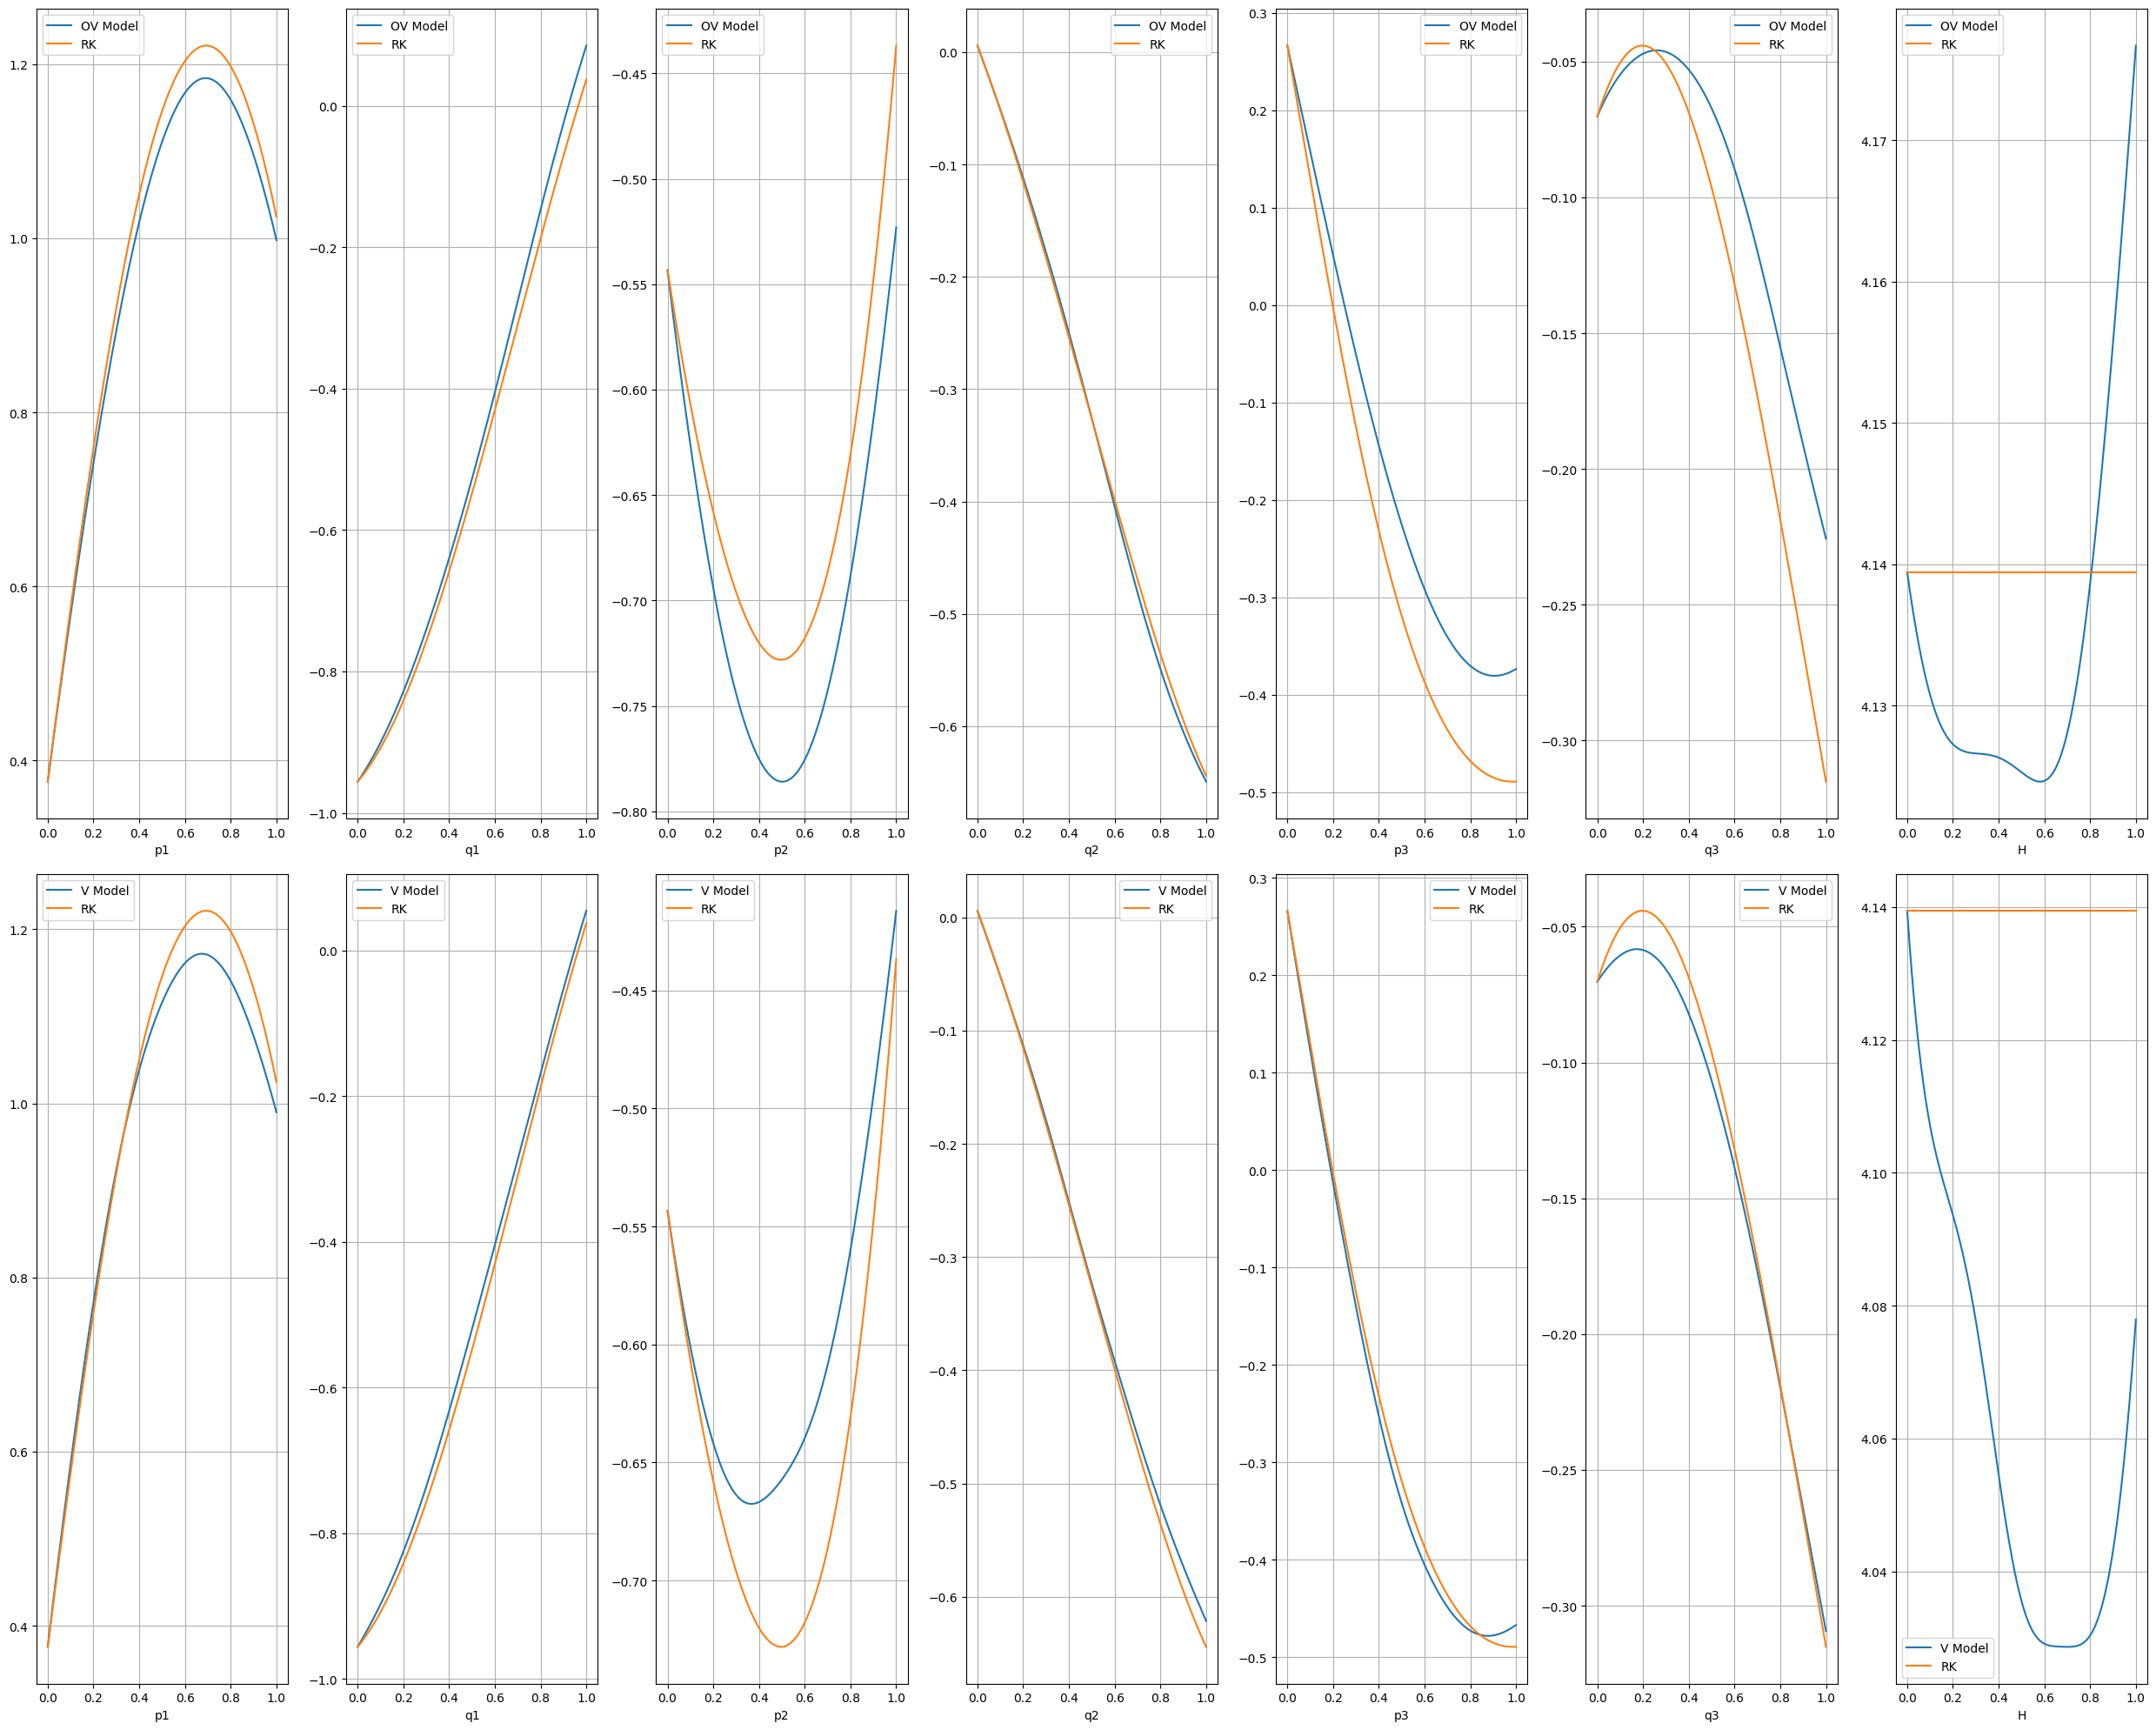

In [113]:
n = 500
t = np.linspace(t0, tfinal, n)

p1_init = np.random.uniform(-1.0, 1.0, size=(1,))[0]
q1_init = np.random.uniform(-1.0, 1.0, size=(1,))[0]
p2_init = np.random.uniform(-1.0, 1.0, size=(1,))[0]
q2_init = np.random.uniform(-1.0, 1.0, size=(1,))[0]
p3_init = np.random.uniform(-1.0, 1.0, size=(1,))[0]
q3_init = np.random.uniform(-1.0, 1.0, size=(1,))[0]
H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
evals_init = calc_evals_pq((p1_init, p2_init, p3_init, q1_init, q2_init, q3_init))
e1_init, e2_init, e3_init = evals_init[0], evals_init[1], evals_init[2]

data_model = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
data_model = np.reshape(data_model, (-1,))
data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

He_model = np.column_stack([H_init, e1_init, e2_init, e3_init])
He_model = np.reshape(He_model, (-1,))
He_model = np.repeat(np.expand_dims(He_model, axis=0), n, axis=0)

t_model = np.column_stack([t, He_model])

data_rk = np.column_stack([p1_init, q1_init, p2_init, q2_init, p3_init, q3_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t

sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
p1_rk, q1_rk, p2_rk, q2_rk, p3_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)
H_data = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
tH_data = np.column_stack([t, H_data])

p1ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 0, Eparams)
q1ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 1, Eparams)
p2ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 2, Eparams)
q2ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 3, Eparams)
p3ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 4, Eparams)
q3ov = jax.vmap(Evar_model, [0, 0, None, None])(t_model, data_model, 5, Eparams)
Hov = calc_H(p1ov, p2ov, p3ov, q1ov, q2ov, q3ov)

args_arr = np.column_stack([p1ov, p2ov, p3ov, q1ov, q2ov, q3ov])
e_0_arr = t_model[:, 2:]


xlbfgs, _ = jax.vmap(lbfgs_jit, [0, 0])(args_arr, e_0_arr)

p1lb = xlbfgs[:, 0]
p2lb = xlbfgs[:, 1]
p3lb = xlbfgs[:, 2]
q1lb = xlbfgs[:, 3]
q2lb = xlbfgs[:, 4]
q3lb = xlbfgs[:, 5]
Hlb = calc_H(p1lb, p2lb, p3lb, q1lb, q2lb, q3lb)

p1ov = p1lb 
p2ov = p2lb
p3ov = p3lb
q1ov = q1lb
q2ov = q2lb
q3ov = q3lb
Hov = Hlb

p1v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 0, params)
q1v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 1, params)
p2v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 2, params)
q2v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 3, params)
p3v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 4, params)
q3v = jax.vmap(var_model, [0, 0, None, None])(t_model, data_model, 5, params)
Hv = calc_H(p1v, p2v, p3v, q1v, q2v, q3v)


fig = plt.figure(figsize=(25, 20))

plt.subplot(2, 7, 1)
plt.tight_layout()
plt.plot(t, p1ov, label = 'OV Model')
plt.plot(t, p1_rk, label = 'RK')
plt.xlabel("p1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 2)
plt.tight_layout()
plt.plot(t, q1ov, label = 'OV Model')
plt.plot(t, q1_rk, label = 'RK')
plt.xlabel("q1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 3)
plt.tight_layout()
plt.plot(t, p2ov, label = 'OV Model')
plt.plot(t, p2_rk, label = 'RK')
plt.xlabel("p2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 4)
plt.tight_layout()
plt.plot(t, q2ov, label = 'OV Model')
plt.plot(t, q2_rk, label = 'RK')
plt.xlabel("q2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 5)
plt.tight_layout()
plt.plot(t, p3ov, label = 'OV Model')
plt.plot(t, p3_rk, label = 'RK')
plt.xlabel("p3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 6)
plt.tight_layout()
plt.plot(t, q3ov, label = 'OV Model')
plt.plot(t, q3_rk, label = 'RK')
plt.xlabel("q3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 7)
plt.tight_layout()
plt.plot(t, Hov, label = 'OV Model')
plt.plot(t, H_rk, label = 'RK')
plt.xlabel("H")
plt.grid()
plt.legend()

plt.subplot(2, 7, 8)
plt.tight_layout()
plt.plot(t, p1v, label = 'V Model')
plt.plot(t, p1_rk, label = 'RK')
plt.xlabel("p1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 9)
plt.tight_layout()
plt.plot(t, q1v, label = 'V Model')
plt.plot(t, q1_rk, label = 'RK')
plt.xlabel("q1")
plt.grid()
plt.legend()

plt.subplot(2, 7, 10)
plt.tight_layout()
plt.plot(t, p2v, label = 'V Model')
plt.plot(t, p2_rk, label = 'RK')
plt.xlabel("p2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 11)
plt.tight_layout()
plt.plot(t, q2v, label = 'V Model')
plt.plot(t, q2_rk, label = 'RK')
plt.xlabel("q2")
plt.grid()
plt.legend()

plt.subplot(2, 7, 12)
plt.tight_layout()
plt.plot(t, p3v, label = 'V Model')
plt.plot(t, p3_rk, label = 'RK')
plt.xlabel("p3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 13)
plt.tight_layout()
plt.plot(t, q3v, label = 'V Model')
plt.plot(t, q3_rk, label = 'RK')
plt.xlabel("q3")
plt.grid()
plt.legend()

plt.subplot(2, 7, 14)
plt.tight_layout()
plt.plot(t, Hv, label = 'V Model')
plt.plot(t, H_rk, label = 'RK')
plt.xlabel("H")
plt.grid()
plt.legend()

plt.show()

In [114]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1)) 

    batch_no = t.shape[0]

    t_0 = t[:, :1]
    H_0 = t[:, 1:2]
    eval1_0 = t[:, 2:3]
    eval2_0 = t[:, 3:4]
    eval3_0 = t[:, 4:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
   
    p1_0 = u[:, :1]
    q1_0 = u[:, 1:2]
    p2_0 = u[:, 2:3]
    q2_0 = u[:, 3:4]
    p3_0 = u[:, 4:5]
    q3_0 = u[:, 5:]

    u = jnp.column_stack((p1_0, q1_0, p2_0, q2_0, p3_0, q3_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_q1 = trunk_net[:, self.units:2*self.units]
    trunk_p2 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q2 = trunk_net[:, 3*self.units:4*self.units]
    trunk_p3 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q3 = trunk_net[:, 5*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_q1 = branch_net[:, self.units:2*self.units]
    branch_p2 = branch_net[:, 2*self.units:3*self.units]
    branch_q2 = branch_net[:, 3*self.units:4*self.units]
    branch_p3 = branch_net[:, 4*self.units:5*self.units]
    branch_q3 = branch_net[:, 5*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    q3 = CombineBranches()(trunk_q3, branch_q3)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])

    pq_arr = jnp.reshape(jnp.column_stack((p1, p2, p3, q1, q2, q3)), (batch_no, 6))
    e_arr = jnp.reshape(jnp.column_stack((eval1_0, eval2_0, eval3_0)), (batch_no, 3))
      
    pq, _ = jax.vmap(lbfgs_jit, [0, 0])(pq_arr, e_arr)
    p1, p2, p3, q1, q2, q3 = pq[:, :1], pq[:, 1:2], pq[:, 2:3], pq[:, 3:4], pq[:, 4:5], pq[:, 5:]
            
    p1 = jnp.reshape(p1, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    q3 = jnp.reshape(q3, (-1,))

    evals = jax.vmap(calc_evals_pq, [0])((p1, p2, p3, q1, q2, q3))

    eval1 = evals[:, :1]
    eval2 = evals[:, 1:2]
    eval3 = evals[:, 2:]

    eval1 = jnp.reshape(eval1, (-1,))
    eval2 = jnp.reshape(eval2, (-1,))
    eval3 = jnp.reshape(eval3, (-1,))

    return p1, q1, p2, q2, p3, q3, eval1, eval2, eval3

In [115]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)       
    
@jax.jit
def Closs(params, t, z):
    
    p1_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    q2_t_loss_w = 1.0
    p3_t_loss_w = 1.0
    q3_t_loss_w = 1.0    
    
    diff_loss_w = 1.0
    H_loss_w = 1.0
    eval1_loss_w = 0.0
    eval2_loss_w = 0.0
    eval3_loss_w = 0.0

    t_0 = t[:, :1]
    
    H_0 = rem_dim(t[:, 1:2])
    eval1_0 = rem_dim(t[:, 2:3])
    eval2_0 = rem_dim(t[:, 3:4])
    eval3_0 = rem_dim(t[:, 4:])
    
    p1_0 = z[:, :1]
    q1_0 = z[:, 1:2]
    p2_0 = z[:, 2:3]
    q2_0 = z[:, 3:4]
    p3_0 = z[:, 4:5]
    q3_0 = z[:, 5:]

    p1 = Cvar(t, z, 0, params)
    q1 = Cvar(t, z, 1, params)
    p2 = Cvar(t, z, 2, params)
    q2 = Cvar(t, z, 3, params)
    p3 = Cvar(t, z, 4, params)
    q3 = Cvar(t, z, 5, params)
    eval1 = Cvar(t, z, 6, params)
    eval2 = Cvar(t, z, 7, params)
    eval3 = Cvar(t, z, 8, params)
    
    H = calc_H(p1, p2, p3, q1, q2, q3)
    
    dp1_t = Cvar_t(t, z, 0, params)
    dq1_t = Cvar_t(t, z, 1, params)
    dp2_t = Cvar_t(t, z, 2, params)
    dq2_t = Cvar_t(t, z, 3, params)
    dp3_t = Cvar_t(t, z, 4, params)
    dq3_t = Cvar_t(t, z, 5, params)
    deval1_t = Cvar_t(t, z, 6, params)
    deval2_t = Cvar_t(t, z, 7, params)
    deval3_t = Cvar_t(t, z, 8, params)
        
    p1_t = dp1_t[:, 0]
    q1_t = dq1_t[:, 0]  
    p2_t = dp2_t[:, 0]
    q2_t = dq2_t[:, 0]
    p3_t = dp3_t[:, 0]
    q3_t = dq3_t[:, 0]
    eval1_t = deval1_t[:, 0]
    eval2_t = deval2_t[:, 0]
    eval3_t = deval3_t[:, 0]

    evals_t_loss = jnp.mean(eval1_t**2) + jnp.mean(eval2_t**2) + jnp.mean(eval3_t**2)

    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q3 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q1))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)
        
    diff_loss = p1_t_loss_w*p1_t_loss +  q1_t_loss_w*q1_t_loss + p2_t_loss_w*p2_t_loss + q2_t_loss_w*q2_t_loss + \
                p3_t_loss_w*p3_t_loss + q3_t_loss_w*q3_t_loss


    evals_loss = jnp.mean((eval1 - eval1_0)**2) + jnp.mean((eval2 - eval2_0)**2) + jnp.mean((eval3 - eval3_0)**2)

    total_loss = diff_loss_w*diff_loss + H_loss
    
    return total_loss, evals_loss

@jax.jit
def Ctrain_step(params, pdes, z):
    t = pdes[:, :]
    
    return jax.value_and_grad(Closs, has_aux = True)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [116]:
def Ctrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            print("new bactch")

            losses, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)

            loss, aux_loss = losses
           
            epoch_loss[i] += loss
            epoch_aux_loss[i] += aux_loss

        epoch_loss[i] /= batch_size
        epoch_aux_loss[i] /= batch_size

        if i % 1  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

    return params, epoch_loss

In [117]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 5), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 6), 1.0, dtype = jnp.float64)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [ ]:
epochs = 200
Cparams, Closs = Ctrain_network(Cparams, de_points, zsensors, epochs)

plt.semilogy(Closs)
plt.grid()

batch size: 100
new bactch
